# Lección 3.3 · Matrices de sustitución (PAM, BLOSUM) y penalizaciones de huecos

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/juvenalyosa/bioinformatica-practica/blob/main/modulo-03-alineamiento/3.3_matrices_sustitucion.ipynb) [![Copiloto: Claude](https://img.shields.io/badge/Copiloto-Claude-D97757?logo=claude&logoColor=white)](https://claude.ai) [![Licencia: MIT](https://img.shields.io/badge/Licencia-MIT-2a78d6.svg)](https://github.com/juvenalyosa/bioinformatica-practica/blob/main/LICENSE)

**Módulo 3 — Alineamiento de secuencias** · Bioinformática Práctica (Maestría)

👤 **Juvenal Yosa, PhD** · ✉️ [juvenal.yosa@gmail.com](mailto:juvenal.yosa@gmail.com) · 🤖 Copiloto: **Claude** (Anthropic)

| ⏱️ Duración | 📶 Nivel | 🧰 Requisitos |
|---|---|---|
| ~3 horas | Intermedio | Lecciones 0.1–0.3, 1.1 y 3.1–3.2 |

---

## 🎯 Objetivos de aprendizaje

Al terminar esta clase usted podrá:

1. **Explicar** por qué, al comparar proteínas, no todos los desajustes valen lo mismo (química y código genético).
2. **Interpretar** un puntaje de sustitución como un **log-odds**: cuántas veces más probable es un par bajo
   homología que por azar.
3. **Construir** una matriz tipo BLOSUM desde cero, a mano y con código, y **compararla** con BLOSUM62.
4. **Modelar** la evolución de proteínas como una **cadena de Márkov** y obtener matrices tipo PAM con potencias
   de matrices.
5. **Medir** la información de una matriz con la **entropía relativa** y **elegir** la matriz según la divergencia.
6. **Distinguir** penalizaciones de huecos lineales y afines, y **calcularlas** a mano.
7. **Demostrar** experimentalmente, con globinas reales, que la elección de la matriz decide si detectamos o no una
   homología lejana.

## 🗺️ Mapa de la clase

1. No todos los desajustes son iguales
2. El puntaje como apuesta: log-odds
3. 🧪 BLOSUM desde cero: de bloques alineados a una matriz
4. Leer BLOSUM62 como un mapa químico
5. PAM: la evolución como cadena de Márkov (🎬 animación)
6. ¿Cuánta información trae una matriz? Entropía relativa
7. Un vistazo al ADN: transiciones y transversiones
8. Huecos: lineales contra afines (🎬 animación)
9. 🧪 Experimento: ¿qué matriz encuentra a la mioglobina?
10. Ejercicios, resumen y lecturas

In [1]:
# ⚙️ Configuración del entorno (ejecute esta celda primero)
# Bioinformática Práctica · Juvenal Yosa, PhD · Copiloto: Claude
import os, sys, urllib.request

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# Descarga el estilo gráfico del curso (en Colab) o lo toma del repositorio (local)
STYLE_URL = "https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main/utils/estilo_curso.py"
if os.path.exists("../utils/estilo_curso.py"):
    sys.path.insert(0, "../utils")
elif not os.path.exists("estilo_curso.py"):
    urllib.request.urlretrieve(STYLE_URL, "estilo_curso.py")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import estilo_curso as ec

ec.set_style()
print("Entorno listo ✔  |  Colab:", IN_COLAB)

import urllib.request
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy.optimize import brentq
from scipy.linalg import logm, expm

try:
    import Bio
except ImportError:
    %pip install -q biopython
from Bio import SeqIO
from Bio.Align import substitution_matrices, PairwiseAligner
from Bio.Data import CodonTable

RAW = "https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main"
AA = "ARNDCQEGHILKMFPSTWYV"                       # los 20 aminoácidos, orden estándar

Entorno listo ✔  |  Colab: False


## 1. No todos los desajustes son iguales

Imagine que corrige exámenes de ortografía. Un estudiante escribe **"caza"** en lugar de **"casa"**; otro escribe
**"cxsa"**. Ambos cometieron **un** error de una letra, pero usted sabe que el primero es mucho más "razonable": la
*s* y la *z* suenan igual en buena parte del mundo hispanohablante, mientras que la *x* no tiene nada que ver.
Un buen corrector no cuenta errores: **pondera** cada error según qué tan plausible es.

Con las proteínas ocurre exactamente lo mismo. Cuando comparamos dos proteínas emparentadas, las diferencias que
vemos son **mutaciones que la selección natural dejó pasar**. Y la selección es exigente: un cambio que conserva la
química del residuo (por ejemplo, **isoleucina → valina**, dos aminoácidos hidrofóbicos casi del mismo tamaño) suele
tolerarse; un cambio que la destruye (por ejemplo, **triptófano → glicina**, el más grande por el más pequeño) casi
nunca sobrevive.

Hay dos fuerzas que hacen que algunos cambios sean frecuentes y otros raros:

| Fuerza | Idea | Ejemplo |
|---|---|---|
| **Química** | la proteína debe seguir plegándose y funcionando | I ↔ V ↔ L (hidrofóbicos) son intercambiables |
| **Código genético** | algunos cambios requieren 1 mutación de ADN, otros 2 o 3 | Asp (GAU) → Glu (GAA): 1 cambio; Trp (UGG) → Asn (AAU/AAC): 3 cambios |

Una **matriz de sustitución** es la tabla de 20 × 20 números que resume esta experiencia: un número **positivo**
para pares que se intercambian a menudo entre proteínas homólogas, **negativo** para pares que casi nunca se ven.

### Los aminoácidos en un mapa químico

Ubiquemos los 20 aminoácidos según dos propiedades: su **hidrofobicidad** (escala de Kyte y Doolittle: positiva =
le "huye" al agua) y su **volumen**. Los colores son las clases fisicoquímicas que usamos desde la Lección 0.2.

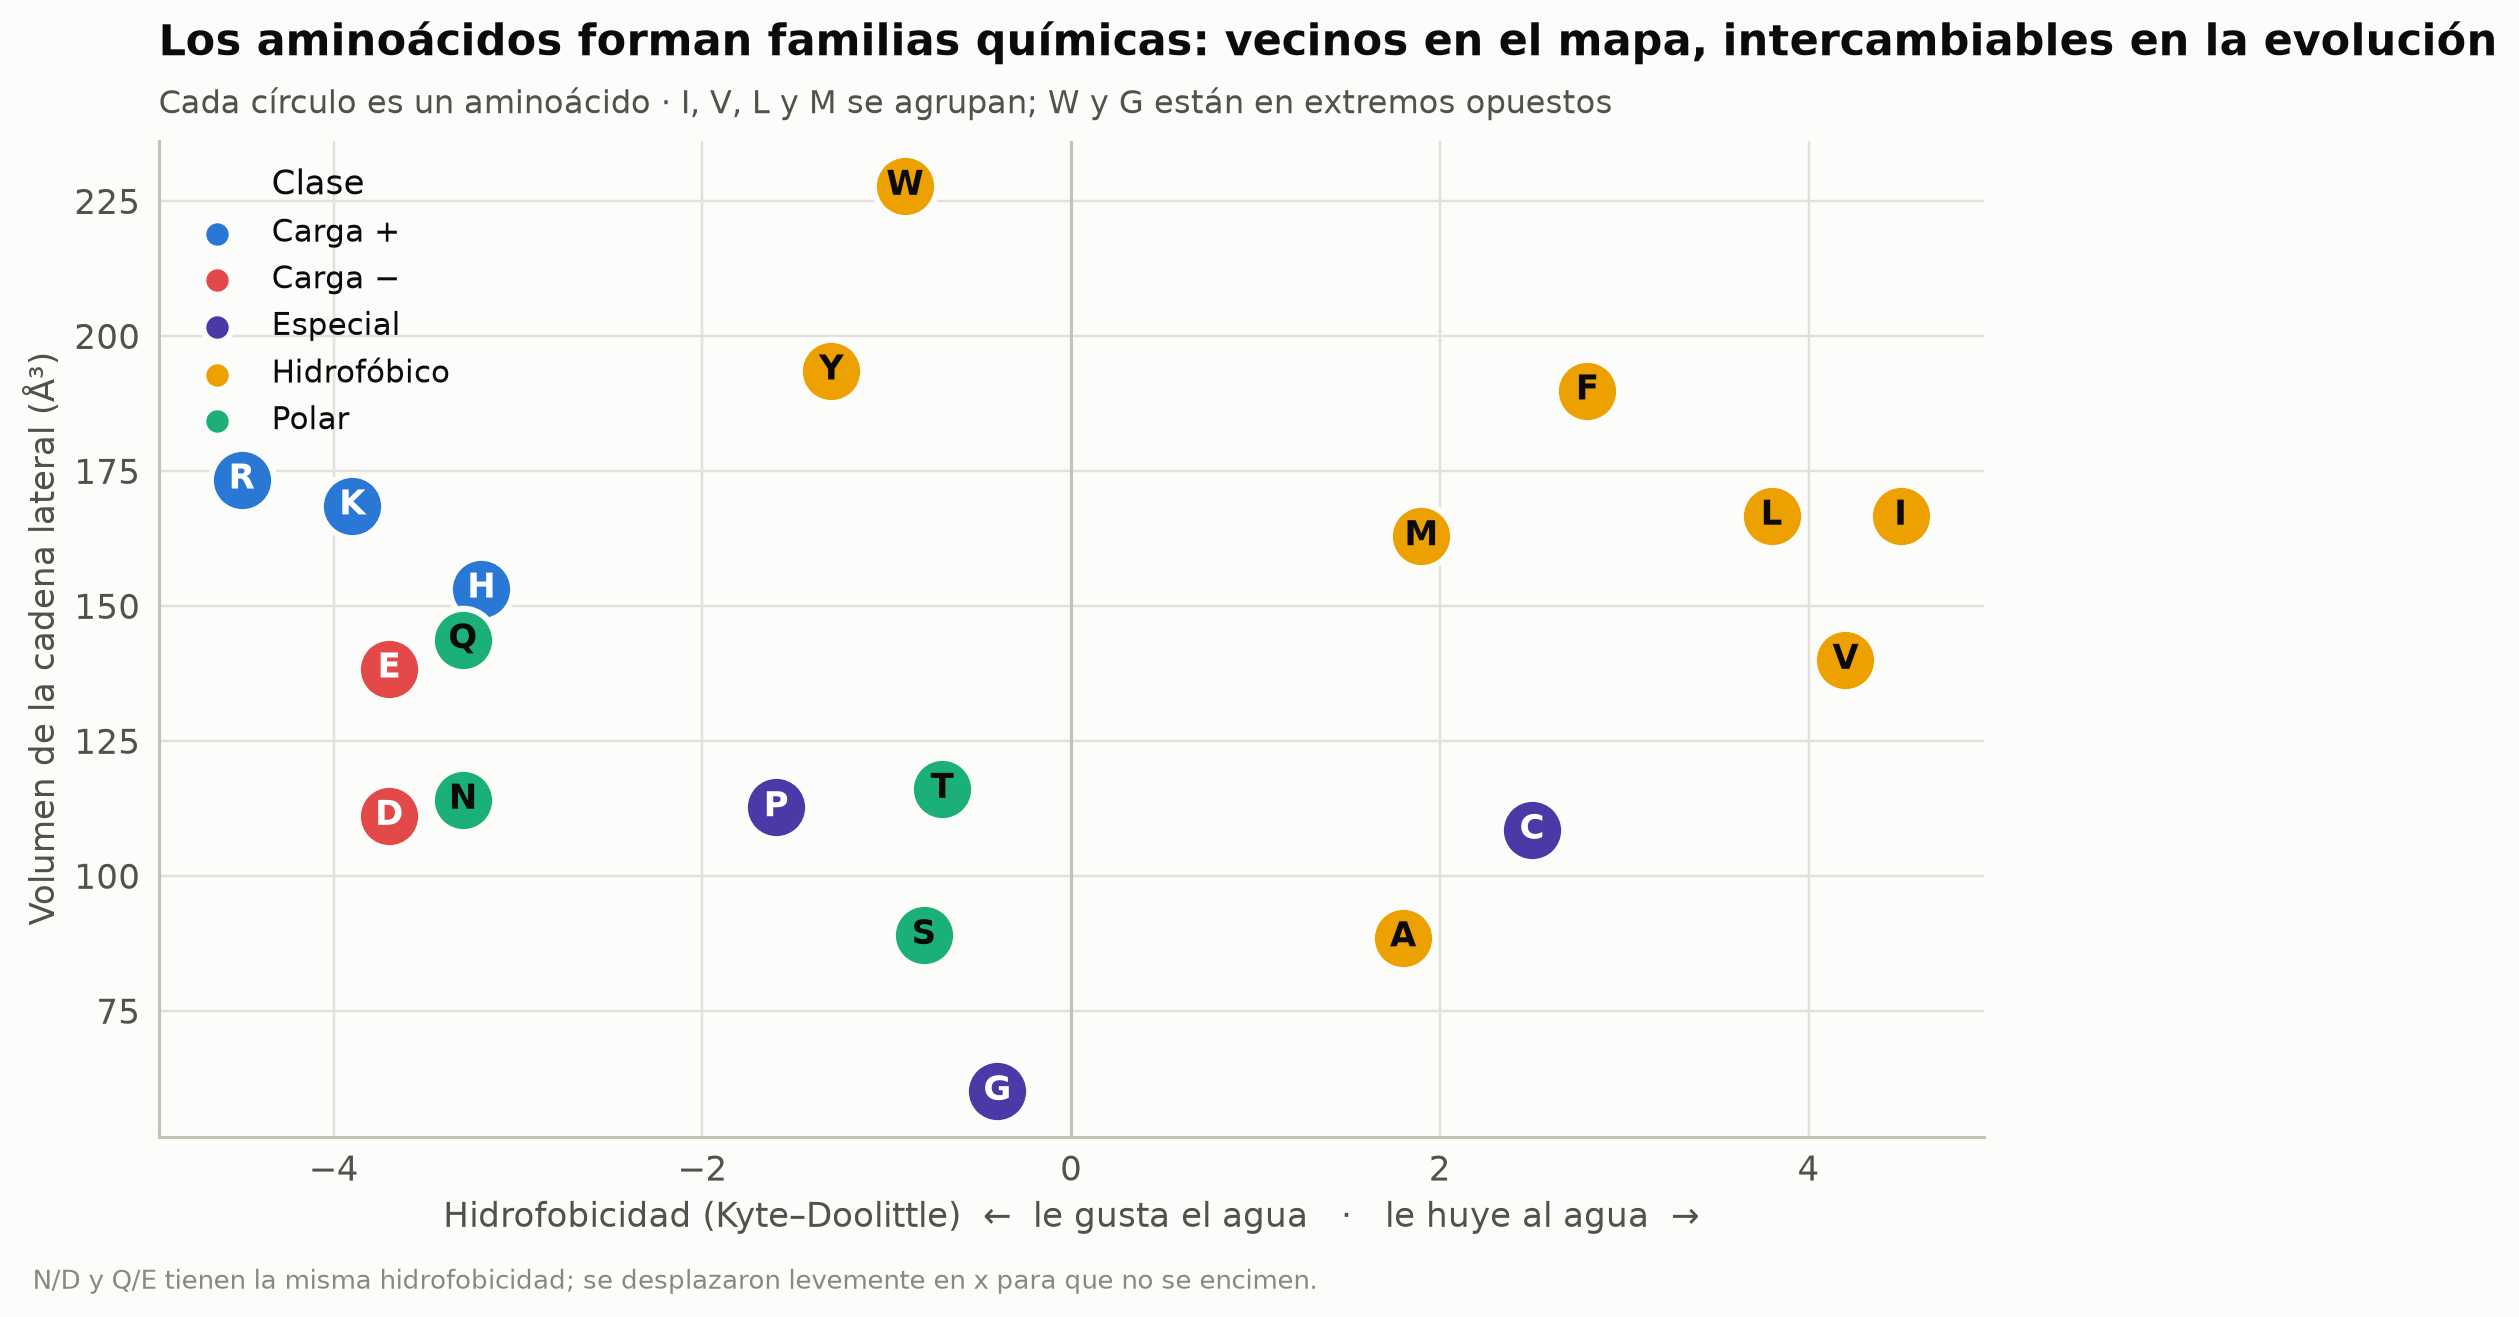

In [2]:
# Hidrofobicidad (Kyte & Doolittle, 1982) y volumen de la cadena lateral (Å³, Zamyatnin, 1972)
kd = dict(A=1.8, R=-4.5, N=-3.5, D=-3.5, C=2.5, Q=-3.5, E=-3.5, G=-0.4, H=-3.2, I=4.5,
          L=3.8, K=-3.9, M=1.9, F=2.8, P=-1.6, S=-0.8, T=-0.7, W=-0.9, Y=-1.3, V=4.2)
vol = dict(A=88.6, R=173.4, N=114.1, D=111.1, C=108.5, Q=143.8, E=138.4, G=60.1, H=153.2, I=166.7,
           L=166.7, K=168.6, M=162.9, F=189.9, P=112.7, S=89.0, T=116.1, W=227.8, Y=193.6, V=140.0)
aa_class = {**{a: "Hidrofóbico" for a in "AVILMFWY"}, **{a: "Polar" for a in "STNQ"},
            **{a: "Carga +" for a in "KRH"}, **{a: "Carga −" for a in "DE"}, **{a: "Especial" for a in "GPC"}}
class_color = {"Hidrofóbico": ec.YELLOW, "Polar": ec.AQUA, "Carga +": ec.BLUE,
               "Carga −": ec.RED, "Especial": ec.VIOLET}
props = pd.DataFrame({"aa": list(AA), "kd": [kd[a] for a in AA], "vol": [vol[a] for a in AA],
                      "clase": [aa_class[a] for a in AA]})
nudge = {"D": -0.2, "E": -0.2, "N": 0.2, "Q": 0.2}        # N/D y Q/E tienen la misma hidrofobicidad
props["x_plot"] = props["kd"] + props["aa"].map(nudge).fillna(0)

fig, ax = plt.subplots(figsize=(9, 5.6))
for cls, sub in props.groupby("clase"):
    ax.scatter(sub["x_plot"], sub["vol"], s=430, color=class_color[cls], edgecolor=ec.SURFACE, linewidth=2,
               label=cls, zorder=3)
for _, r in props.iterrows():
    ax.text(r["x_plot"], r["vol"], r["aa"], ha="center", va="center", fontsize=11, fontweight="bold",
            color="white" if r["clase"] in ("Carga +", "Especial", "Carga −") else ec.INK, zorder=4)
ax.axvline(0, color=ec.BASELINE, lw=1, zorder=1)
ax.set_xlabel("Hidrofobicidad (Kyte–Doolittle)  ←  le gusta el agua   ·   le huye al agua  →")
ax.set_ylabel("Volumen de la cadena lateral (Å³)")
ax.grid(True, axis="both")
ax.legend(loc="upper left", ncol=1, title="Clase", markerscale=0.45)
ec.title(ax, "Los aminoácidos forman familias químicas: vecinos en el mapa, intercambiables en la evolución",
         "Cada círculo es un aminoácido · I, V, L y M se agrupan; W y G están en extremos opuestos")
ec.source(fig, "N/D y Q/E tienen la misma hidrofobicidad; se desplazaron levemente en x para que no se encimen.")
plt.show()

> 🔎 **Qué observamos.** I, L, V, M y F forman un grupo compacto (hidrofóbicos y voluminosos); D, E, N, Q, K y R se
> agrupan en el lado hidrofílico; G, el más pequeño, y W, el más grande, quedan aislados. Si la evolución favorece
> los cambios "baratos", deberíamos ver que **los pares cercanos en este mapa tienen puntajes altos** en una matriz
> de sustitución real. Lo comprobaremos en la sección 4.

### El código genético también reparte las cartas

Para pasar de un aminoácido a otro, el ADN tiene que mutar. Si los codones de ambos aminoácidos difieren en una sola
base, el cambio puede ocurrir con **una** mutación; si difieren en tres bases, hacen falta **tres** mutaciones
consecutivas en el mismo codón, algo mucho más raro. Calculemos, para cada par de aminoácidos, el **mínimo número de
cambios de nucleótido** necesario.

In [3]:
table = CodonTable.unambiguous_dna_by_id[1].forward_table          # codón → aminoácido
codons_of = {a: [c for c, x in table.items() if x == a] for a in AA}

def min_nt_changes(a: str, b: str) -> int:
    """Mínimo número de sustituciones de nucleótido para pasar de un codón de `a` a uno de `b`."""
    return min(sum(x != y for x, y in zip(c1, c2)) for c1 in codons_of[a] for c2 in codons_of[b])

print("Asp → Glu :", min_nt_changes("D", "E"), "cambio")
print("Ile → Val :", min_nt_changes("I", "V"), "cambio")
print("Trp → Asn :", min_nt_changes("W", "N"), "cambios")

Asp → Glu : 1 cambio
Ile → Val : 1 cambio
Trp → Asn : 3 cambios


## 2. El puntaje como apuesta: log-odds

Toda matriz de sustitución moderna responde a **una sola pregunta** para cada par de aminoácidos $a$ y $b$ que
aparecen alineados:

> ¿Es más probable ver este par porque las dos proteínas **comparten un ancestro** (homología), o simplemente
> **por azar**, porque tomé dos aminoácidos cualesquiera?

Es como un apostador que compara dos explicaciones de lo que ve. La razón entre ambas probabilidades se llama
**odds** (momios), y su logaritmo es el **log-odds**:

$$
\boxed{\;s(a,b) \;=\; \frac{1}{\lambda}\,\log\!\left(\frac{q_{ab}}{p_a\,p_b}\right)\;}
$$

| Símbolo | Significado |
|---|---|
| $s(a,b)$ | puntaje de alinear $a$ con $b$ (el número que aparece en la matriz) |
| $q_{ab}$ | probabilidad de ver el par $a$–$b$ alineado en **proteínas homólogas** reales ("frecuencia objetivo") |
| $p_a,\ p_b$ | frecuencia de fondo de cada aminoácido (qué tan común es en las proteínas en general) |
| $p_a\,p_b$ | probabilidad de ver el par **por azar**: dos aminoácidos tomados independientemente |
| $\log$ | convierte razones en sumas (ver abajo) |
| $\lambda$ | factor de escala; con $\lambda = \tfrac{\ln 2}{2}$ el puntaje queda en **medios bits** (BLOSUM62) |

**Cómo leer el signo:**

* $s > 0$ → $q_{ab} > p_a p_b$: el par aparece **más** de lo que el azar explica → evidencia de homología.
* $s = 0$ → el par aparece justo lo esperado por azar → no aporta evidencia.
* $s < 0$ → el par aparece **menos** que por azar → evidencia en contra.

### Ejemplo a mano

Supongamos que la leucina (L) tiene frecuencia $p_L = 0.10$ y la isoleucina (I) $p_I = 0.06$. Por azar, el par L–I
aparecería con probabilidad $0.10 \times 0.06 = 0.006$. En alineamientos de proteínas homólogas lo vemos con
$q_{LI} = 0.024$. Entonces:

$$
\frac{q_{LI}}{p_L\,p_I} = \frac{0.024}{0.006} = 4
\qquad\Longrightarrow\qquad
s(L,I) = 2\,\log_2 4 = 2 \times 2 = \mathbf{+4}\ \text{medios bits}
$$

El par L–I es **cuatro veces** más frecuente entre homólogos que por azar.

### ¿Por qué el logaritmo?

Un alineamiento sin huecos de $n$ columnas es una serie de pares independientes. La razón de probabilidades del
alineamiento completo es el **producto** de las razones de cada columna, y el logaritmo convierte ese producto en
una **suma**:

$$
\log \prod_{i=1}^{n} \frac{q_{x_i y_i}}{p_{x_i}\,p_{y_i}}
\;=\; \sum_{i=1}^{n} \log \frac{q_{x_i y_i}}{p_{x_i}\,p_{y_i}}
\;\propto\; \sum_{i=1}^{n} s(x_i, y_i)
$$

Por eso **el puntaje de un alineamiento es la suma de los puntajes de sus columnas**: sumar es rápido, y es
justamente lo que hacen los algoritmos de programación dinámica de la Lección 3.2.

In [4]:
def half_bits(q_ab: float, p_a: float, p_b: float) -> float:
    """Puntaje log-odds en medios bits: 2·log2(q / (p_a p_b))."""
    return 2 * np.log2(q_ab / (p_a * p_b))

print("s(L,I) =", half_bits(0.024, 0.10, 0.06), "medios bits")
print("Par que aparece la mitad de lo esperado:", half_bits(0.003, 0.10, 0.06), "medios bits")

s(L,I) = 4.0 medios bits
Par que aparece la mitad de lo esperado: -2.0 medios bits


## 3. 🧪 BLOSUM desde cero: de bloques alineados a una matriz

En 1992, Steven y Jorja Henikoff construyeron las matrices **BLOSUM** (*BLOcks SUbstitution Matrix*) a partir de
miles de **bloques**: fragmentos de proteínas homólogas alineados **sin huecos**, tomados de la base de datos
BLOCKS. La receta es tan sencilla que podemos hacerla a mano.

### Paso a paso con un bloque de juguete

Tomemos cuatro secuencias homólogas, tres columnas cada una:

```
secuencia 1:  A  S  T
secuencia 2:  A  S  S
secuencia 3:  A  T  T
secuencia 4:  S  S  T
```

**Paso 1 — contar pares en cada columna.** Con 4 secuencias hay $\binom{4}{2} = 6$ pares por columna. En una columna
donde el aminoácido $a$ aparece $n_a$ veces y $b$ aparece $n_b$ veces:

$$
f_{aa} = \binom{n_a}{2} = \frac{n_a(n_a-1)}{2}, \qquad f_{ab} = n_a\, n_b \quad (a \ne b)
$$

| Columna | Composición | Pares |
|---|---|---|
| 1 | A, A, A, S | AA: 3 · AS: 3 |
| 2 | S, S, T, S | SS: 3 · ST: 3 |
| 3 | T, S, T, T | TT: 3 · ST: 3 |
| **Total** | | AA 3, AS 3, SS 3, ST 6, TT 3 → **18 pares** |

**Paso 2 — frecuencias objetivo** $q_{ab} = f_{ab} / \sum f$:
$q_{AA} = q_{AS} = q_{SS} = q_{TT} = 3/18 = 0.167$ y $q_{ST} = 6/18 = 0.333$.

**Paso 3 — frecuencias de fondo.** Cada par aporta "medio" aminoácido a cada miembro:

$$
p_a \;=\; q_{aa} + \frac{1}{2}\sum_{b \ne a} q_{ab}
$$

$p_A = 0.167 + 0.167/2 = 0.25$, $\;p_S = 0.167 + (0.167 + 0.333)/2 = 0.417$, $\;p_T = 0.167 + 0.333/2 = 0.333$.

**Paso 4 — frecuencias esperadas por azar.** Para un par igual $e_{aa} = p_a^2$; para un par distinto
$e_{ab} = 2\,p_a p_b$ (el 2 porque A–S y S–A son el mismo par desordenado).

**Paso 5 — puntaje** $s_{ab} = \mathrm{redondeo}\!\left[\,2\log_2 (q_{ab}/e_{ab})\,\right]$:

| Par | $q_{ab}$ | $e_{ab}$ | $q/e$ | $2\log_2(q/e)$ | $s_{ab}$ |
|---|---|---|---|---|---|
| A–A | 0.167 | 0.0625 | 2.67 | 2.83 | **+3** |
| T–T | 0.167 | 0.111 | 1.50 | 1.17 | **+1** |
| S–S | 0.167 | 0.174 | 0.96 | −0.12 | **0** |
| S–T | 0.333 | 0.278 | 1.20 | 0.53 | **+1** |
| A–S | 0.167 | 0.208 | 0.80 | −0.64 | **−1** |
| A–T | 0 | 0.167 | 0 | $-\infty$ | **¡problema!** |

> 🔎 **Qué observamos.** La alanina, que se conserva en su columna, recibe el puntaje más alto; S–T, intercambio
> frecuente entre dos aminoácidos pequeños con grupo –OH, sale positivo. Pero A–T **nunca** apareció, y su log-odds
> es $-\infty$: con pocos datos, "no lo he visto" no significa "es imposible". La solución práctica es sumar una
> pequeña **pseudocuenta** a todos los pares antes de calcular. Con miles de bloques reales el problema casi
> desaparece.

Verifiquemos el cálculo con código:

In [5]:
from itertools import combinations
from collections import Counter

def blosum_from_blocks(blocks, alphabet, pseudocount=0.0):
    """Matriz tipo BLOSUM (medios bits) a partir de bloques alineados sin huecos."""
    idx = {a: i for i, a in enumerate(alphabet)}
    f = np.full((len(alphabet), len(alphabet)), pseudocount)
    for block in blocks:
        for col in zip(*block):                                   # recorremos las columnas
            for x, y in combinations(col, 2):                     # todos los pares de la columna
                if x in idx and y in idx:
                    i, j = idx[x], idx[y]
                    f[i, j] += 0.5; f[j, i] += 0.5                # matriz simétrica
    q = f / f.sum()                                               # frecuencias objetivo q_ab
    p = q.sum(axis=1)                                             # frecuencias de fondo p_a
    e = np.outer(p, p)                                            # esperado por azar (orden incluido)
    with np.errstate(divide="ignore"):
        s = 2 * np.log2(q / e)
    return pd.DataFrame(s, index=list(alphabet), columns=list(alphabet)), p

toy = [["AST", "ASS", "ATT", "SST"]]
s_toy, p_toy = blosum_from_blocks(toy, "AST")
print("p =", {a: round(float(v), 3) for a, v in zip("AST", p_toy)})
print("\nSin pseudocuenta (medios bits, sin redondear):")
print(s_toy.round(2))
print("\nCon pseudocuenta 0.5 y redondeo:")
print(blosum_from_blocks(toy, "AST", pseudocount=0.5)[0].round(0) + 0.0)   # +0.0 evita "-0"

p = {'A': 0.25, 'S': 0.417, 'T': 0.333}

Sin pseudocuenta (medios bits, sin redondear):
      A     S     T
A  2.83 -0.64  -inf
S -0.64 -0.12  0.53
T  -inf  0.53  1.17

Con pseudocuenta 0.5 y redondeo:
     A    S    T
A  2.0 -1.0 -4.0
S -1.0  0.0  0.0
T -4.0  0.0  1.0


> ✅ **Compruebe su comprensión.** En el código usamos $q/(p_a p_b)$ con la matriz completa (A–S y S–A por separado,
> cada una con la mitad de las cuentas). ¿Por qué da lo mismo que la tabla, donde usamos el par desordenado con
> $e_{ab} = 2p_ap_b$? *(Pista: divida numerador y denominador entre 2.)*

### Ahora con proteínas reales: la familia de las globinas

Vamos a usar cinco globinas reales de UniProt: hemoglobina β y α humanas, hemoglobina β de ratón, y mioglobina humana
y de cachalote. Todas descienden de un gen ancestral común, pero se separaron en momentos muy distintos:

| Par | Relación | Divergencia |
|---|---|---|
| HBB humana – HBB ratón | **ortólogos** (mismo gen, especies distintas) | baja |
| HBB – HBA humanas | **parálogos** (duplicación antigua) | media |
| HBB – mioglobina humanas | parálogos muy antiguos | alta ("zona de penumbra") |

In [6]:
def load_globins(path_local="../data/globins.fasta"):
    """Lee las globinas: copia local del curso → GitHub → UniProt."""
    if os.path.exists(path_local):
        return list(SeqIO.parse(path_local, "fasta"))
    try:
        urllib.request.urlretrieve(f"{RAW}/data/globins.fasta", "globins.fasta")
    except Exception:
        ids = ["P68871", "P69905", "P02144", "P02088", "P02185"]
        text = "".join(urllib.request.urlopen(f"https://rest.uniprot.org/uniprotkb/{i}.fasta").read().decode()
                       for i in ids)
        open("globins.fasta", "w").write(text)
    return list(SeqIO.parse("globins.fasta", "fasta"))

globins = {r.id.split("|")[2]: str(r.seq) for r in load_globins()}
for name, seq in globins.items():
    print(f"{name:12s} {len(seq):4d} aa   {seq[:50]}…")

HBB_HUMAN     147 aa   MVHLTPEEKSAVTALWGKVNVDEVGGEALGRLLVVYPWTQRFFESFGDLS…
HBA_HUMAN     142 aa   MVLSPADKTNVKAAWGKVGAHAGEYGAEALERMFLSFPTTKTYFPHFDLS…
MYG_HUMAN     154 aa   MGLSDGEWQLVLNVWGKVEADIPGHGQEVLIRLFKGHPETLEKFDKFKHL…
HBB1_MOUSE    147 aa   MVHLTDAEKAAVSCLWGKVNSDEVGGEALGRLLVVYPWTQRYFDSFGDLS…
MYG_PHYMC     154 aa   MVLSEGEWQLVLHVWAKVEADVAGHGQDILIRLFKSHPETLEKFDRFKHL…


No tenemos bloques de BLOCKS, pero podemos fabricarlos: alineamos cada par de globinas y nos quedamos con las
**columnas sin huecos**. (Para alinear usamos BLOSUM62, lo que introduce algo de circularidad; en un proyecto real
se usarían alineamientos estructurales. Para aprender el método es suficiente.)

🤔 **Antes de ejecutar, prediga:** con apenas unos cientos de pares de columnas, ¿se parecerá nuestra matriz a
BLOSUM62? ¿Qué pares estarán mejor estimados, los comunes o los raros?

In [7]:
blosum62 = substitution_matrices.load("BLOSUM62")
B62 = pd.DataFrame([[blosum62[a, b] for b in AA] for a in AA], index=list(AA), columns=list(AA))

aligner = PairwiseAligner(mode="global", substitution_matrix=blosum62,
                          open_gap_score=-11, extend_gap_score=-1)

blocks, n_cols = [], 0
names = list(globins)
for x, y in combinations(names, 2):
    aln = aligner.align(globins[x], globins[y])[0]
    ungapped = [(a, b) for a, b in zip(aln[0], aln[1]) if a != "-" and b != "-"]
    n_cols += len(ungapped)
    blocks.append(["".join(a for a, _ in ungapped), "".join(b for _, b in ungapped)])

S_glob, p_glob = blosum_from_blocks(blocks, AA, pseudocount=1.0)
print(f"{len(blocks)} alineamientos por pares · {n_cols:,} columnas sin huecos")
r = np.corrcoef(S_glob.values[np.triu_indices(20)], B62.values[np.triu_indices(20)])[0, 1]
print(f"Correlación con BLOSUM62 (210 pares): r = {r:.2f}")

10 alineamientos por pares · 1,449 columnas sin huecos
Correlación con BLOSUM62 (210 pares): r = 0.79


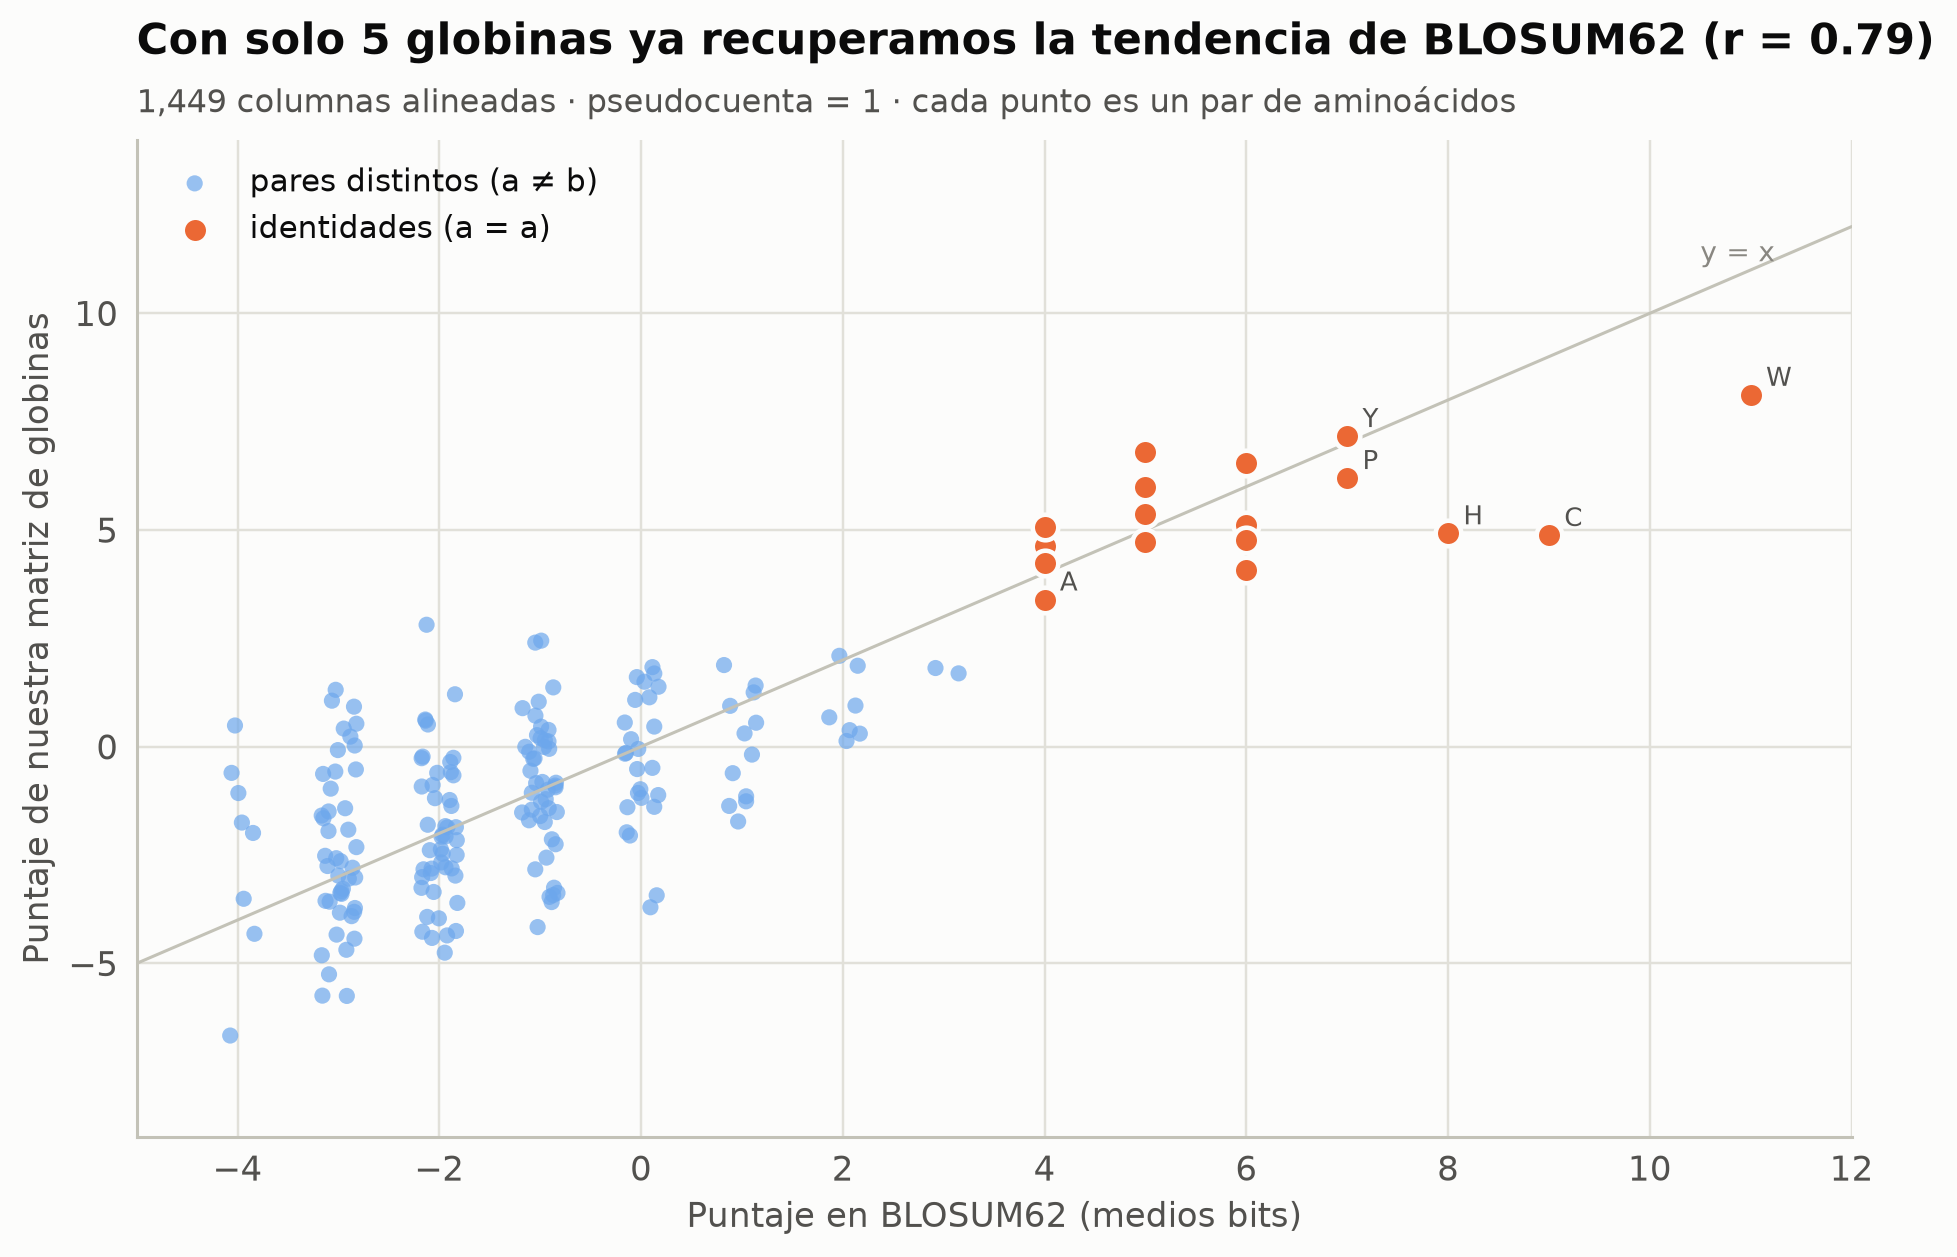

In [8]:
iu = np.triu_indices(20)
comp = pd.DataFrame({"ours": S_glob.values[iu], "b62": B62.values[iu],
                     "pair": [AA[i] + AA[j] for i, j in zip(*iu)], "diag": iu[0] == iu[1]})

fig, ax = plt.subplots(figsize=(8.5, 5.6))
jitter = np.random.default_rng(0).uniform(-0.18, 0.18, len(comp))
off = comp[~comp["diag"]]
ax.scatter(off["b62"] + jitter[~comp["diag"]], off["ours"], s=28, color=ec.SEQ_BLUE[4], alpha=0.7,
           edgecolor="none", label="pares distintos (a ≠ b)")
dg = comp[comp["diag"]]
ax.scatter(dg["b62"], dg["ours"], s=70, color=ec.ORANGE, edgecolor=ec.SURFACE, linewidth=1.5,
           label="identidades (a = a)", zorder=3)
for _, row in dg[dg["pair"].str[0].isin(list("WCHYAP"))].iterrows():     # solo algunas, para no encimar
    ax.annotate(row["pair"][0], (row["b62"], row["ours"]), xytext=(5, 3), textcoords="offset points",
                fontsize=8.5, color=ec.INK_2)
lims = [-6, 12]
ax.plot(lims, lims, color=ec.BASELINE, lw=1)
ax.text(10.5, 11.2, "y = x", color=ec.MUTED, fontsize=9)
ax.set_xlim(-5, 12); ax.set_ylim(-9, 14)
ax.set_xlabel("Puntaje en BLOSUM62 (medios bits)")
ax.set_ylabel("Puntaje de nuestra matriz de globinas")
ax.grid(True, axis="both")
ax.legend(loc="upper left")
ec.title(ax, f"Con solo 5 globinas ya recuperamos la tendencia de BLOSUM62 (r = {r:.2f})",
         f"{n_cols:,} columnas alineadas · pseudocuenta = 1 · cada punto es un par de aminoácidos")
plt.show()

> 🔎 **Qué observamos.** La nube sigue la diagonal: con apenas cinco proteínas ya aparece la estructura de BLOSUM62.
> Las **identidades** (naranja) salen positivas en ambas matrices, y las de aminoácidos raros (W, C) tienen los
> puntajes más altos: conservar un triptófano es muy informativo porque es raro por azar. Los pares distintos están
> mucho más dispersos: muchos pares aparecieron cero o una vez, y ahí manda la pseudocuenta. **La calidad de una
> matriz depende de cuántos datos la respaldan**: BLOSUM62 usó más de 2 000 bloques.

### ¿Y el "62"?

Si una familia tiene muchas secuencias casi idénticas (por ejemplo, 50 hemoglobinas de primates), sus pares
dominarían el conteo. Los Henikoff **agruparon** las secuencias que comparten al menos un $X\,\%$ de identidad y las
contaron como una sola. Con $X = 62$ se obtiene **BLOSUM62**; con $X = 80$, BLOSUM80, que refleja proteínas más
parecidas; con $X = 45$, BLOSUM45, que refleja proteínas más lejanas.

> ⚠️ Es fácil confundirse: en BLOSUM, **número más alto = secuencias más cercanas**. En PAM (sección 5) es al revés.

## 4. Leer BLOSUM62 como un mapa químico

Ordenemos las filas y columnas de BLOSUM62 por **clase química**. Si las matrices capturan la química, deberían
aparecer **bloques azules** (puntajes positivos) dentro de cada clase.

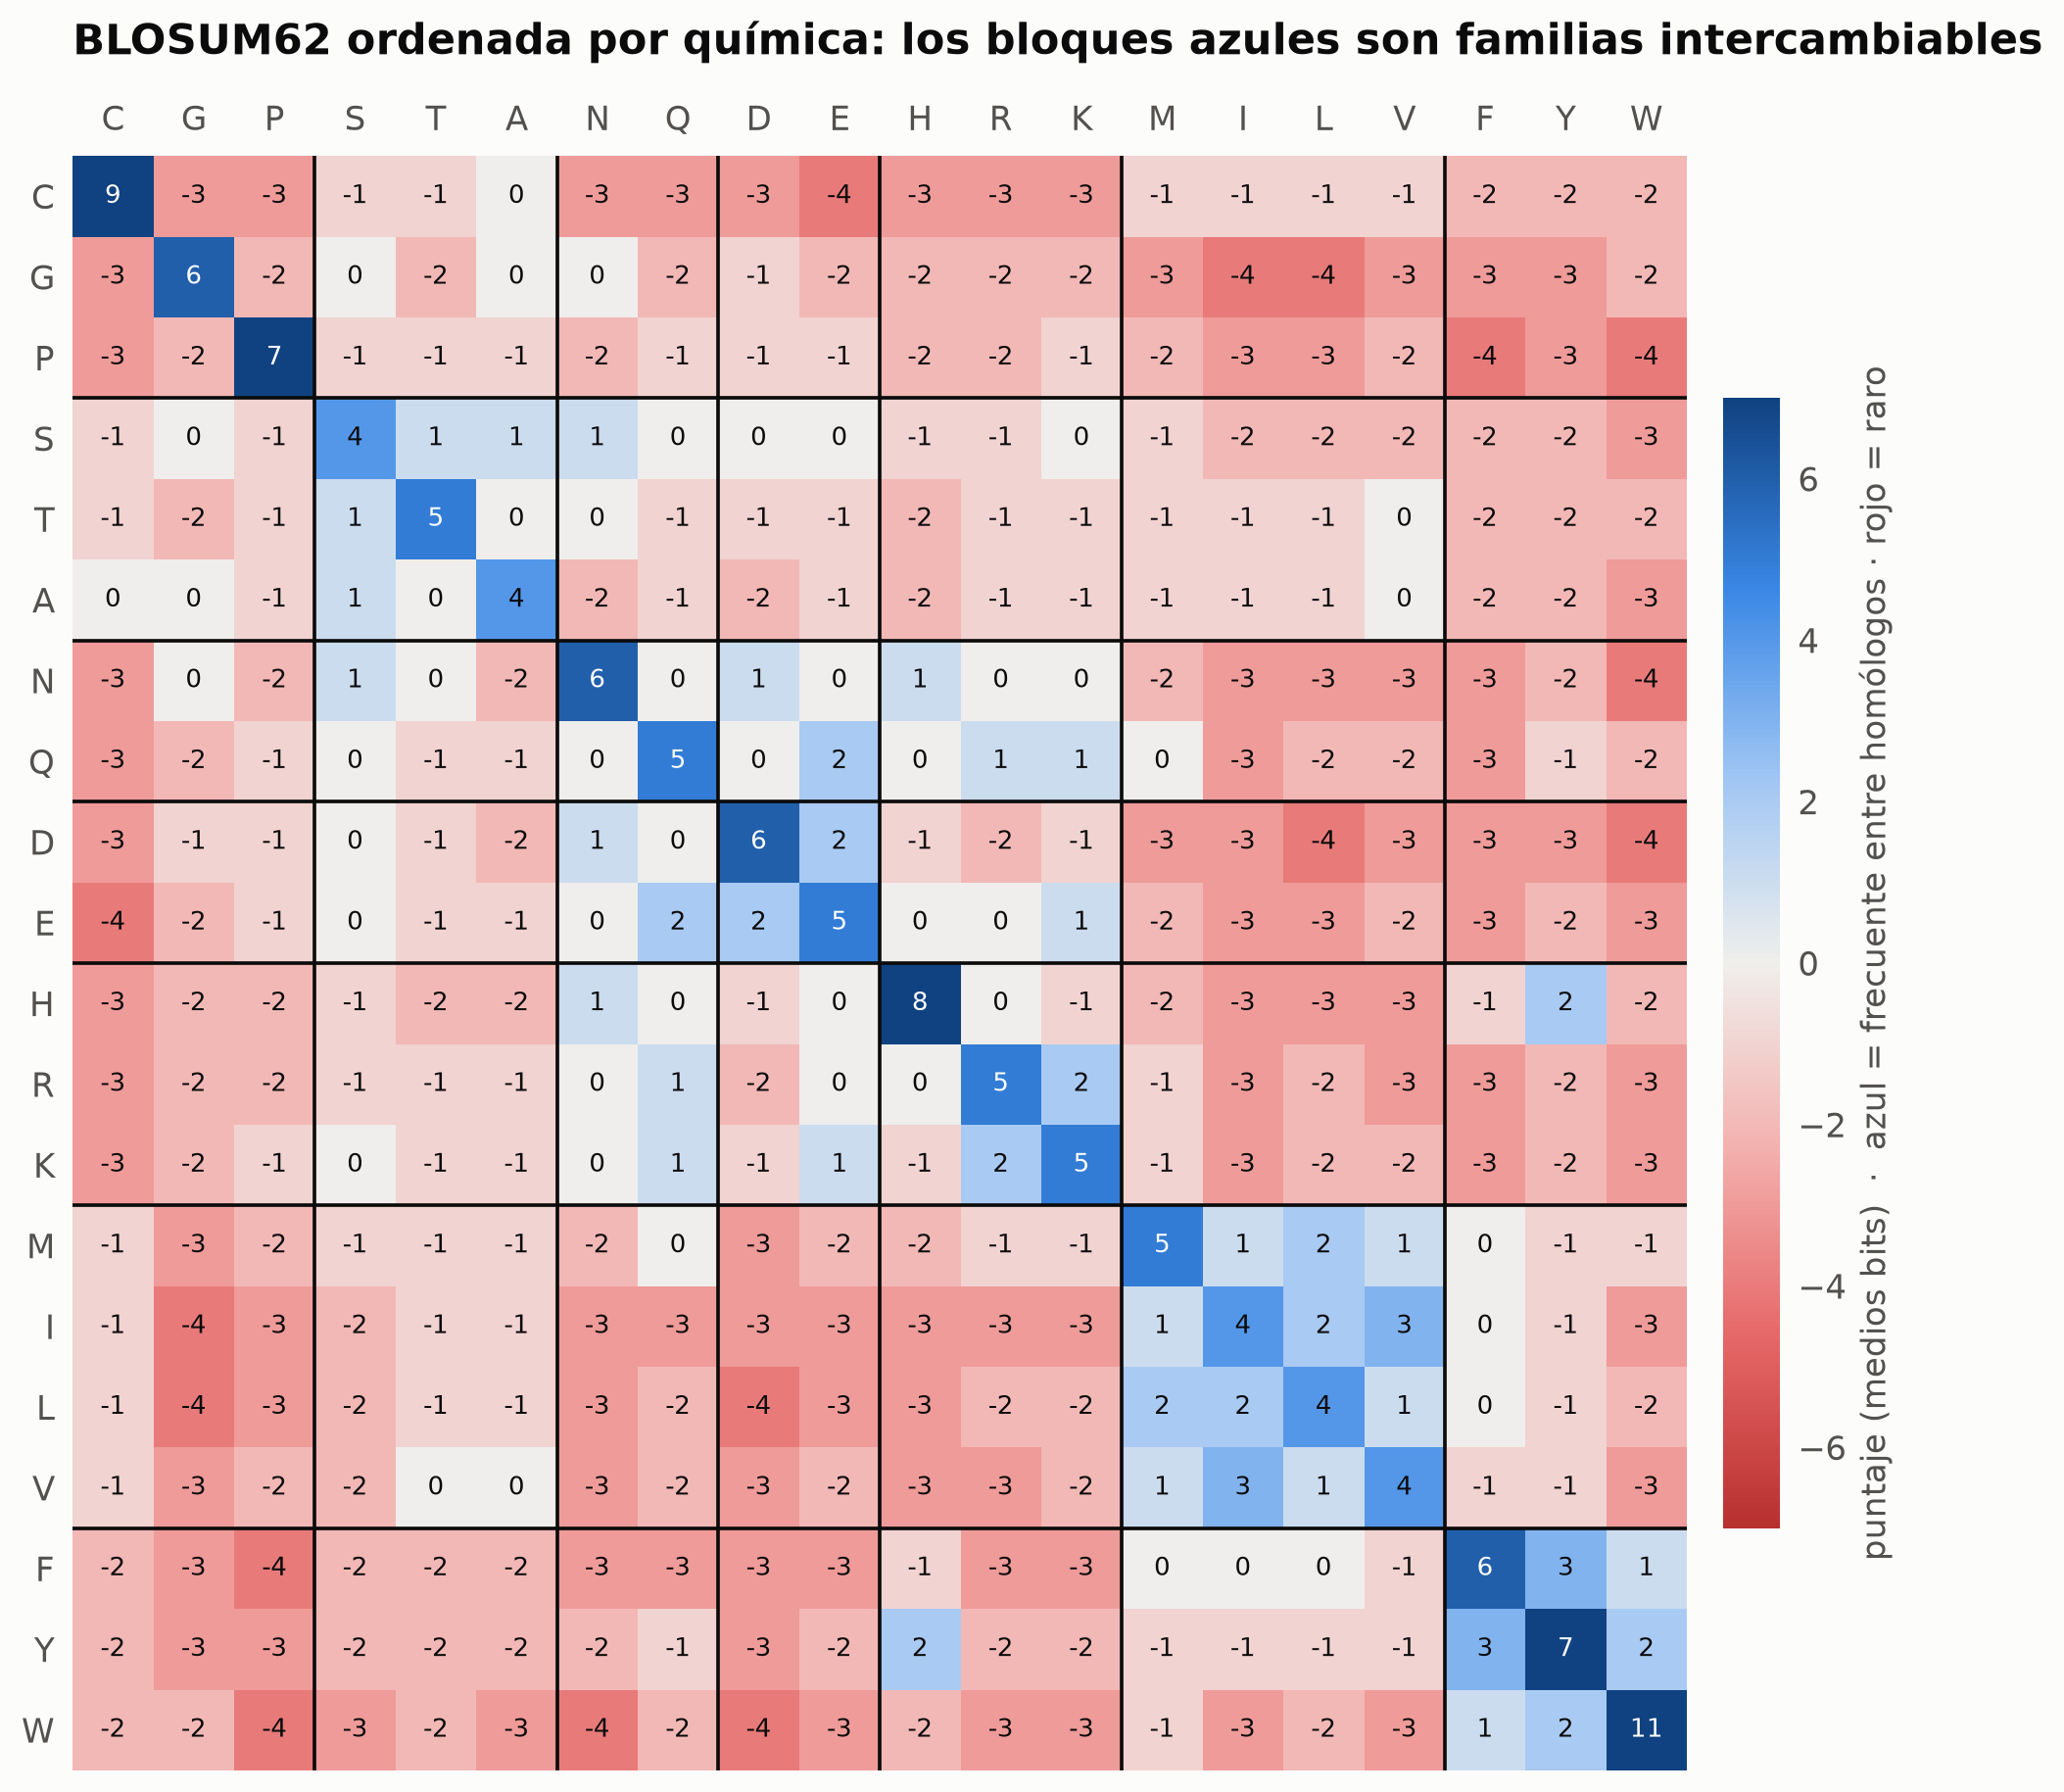

In [9]:
order = list("CGPSTANQDEHRKMILVFYW")
M = B62.loc[order, order]
groups = [("Especial", 0, 3), ("Pequeños", 3, 6), ("Amidas", 6, 8), ("Ácidos", 8, 10), ("Básicos", 10, 13),
          ("Alifáticos", 13, 17), ("Aromáticos", 17, 20)]

fig, ax = plt.subplots(figsize=(9.5, 8.2))
im = ax.imshow(M.values, cmap=ec.CMAP_DIV.reversed(), vmin=-7, vmax=7)
for i in range(20):
    for j in range(20):
        v = M.values[i, j]
        ax.text(j, i, f"{v:.0f}", ha="center", va="center", fontsize=8.5,
                color="white" if abs(v) >= 5 else ec.INK)
ax.set_xticks(range(20), order); ax.set_yticks(range(20), order)
ax.tick_params(labeltop=True, labelbottom=False, length=0)
for _, a, b in groups[1:]:
    ax.axhline(a - 0.5, color=ec.INK, lw=1.2); ax.axvline(a - 0.5, color=ec.INK, lw=1.2)
ax.grid(False)
for s in ax.spines.values(): s.set_visible(False)
cb = fig.colorbar(im, ax=ax, shrink=0.7, pad=0.02)
cb.set_label("puntaje (medios bits)  ·  azul = frecuente entre homólogos · rojo = raro")
cb.outline.set_visible(False)
ax.set_title("BLOSUM62 ordenada por química: los bloques azules son familias intercambiables", loc="left", pad=34)
plt.show()

> 🔎 **Qué observamos.**
> * El bloque **M–I–L–V** es claramente azul: los hidrofóbicos alifáticos se sustituyen entre sí.
> * **F–Y–W** (aromáticos) forman otro bloque; **K–R** (+2) y **D–E** (+2) también.
> * La **diagonal** varía mucho: W–W = +11 y C–C = +9, pero A–A = +4 y S–S = +4. Conservar un aminoácido raro
>   y químicamente único dice mucho más que conservar uno común.
> * **C** (cisteína) es negativa con casi todo: forma puentes disulfuro y rara vez se reemplaza.

Ahora conectemos con las dos fuerzas de la sección 1:

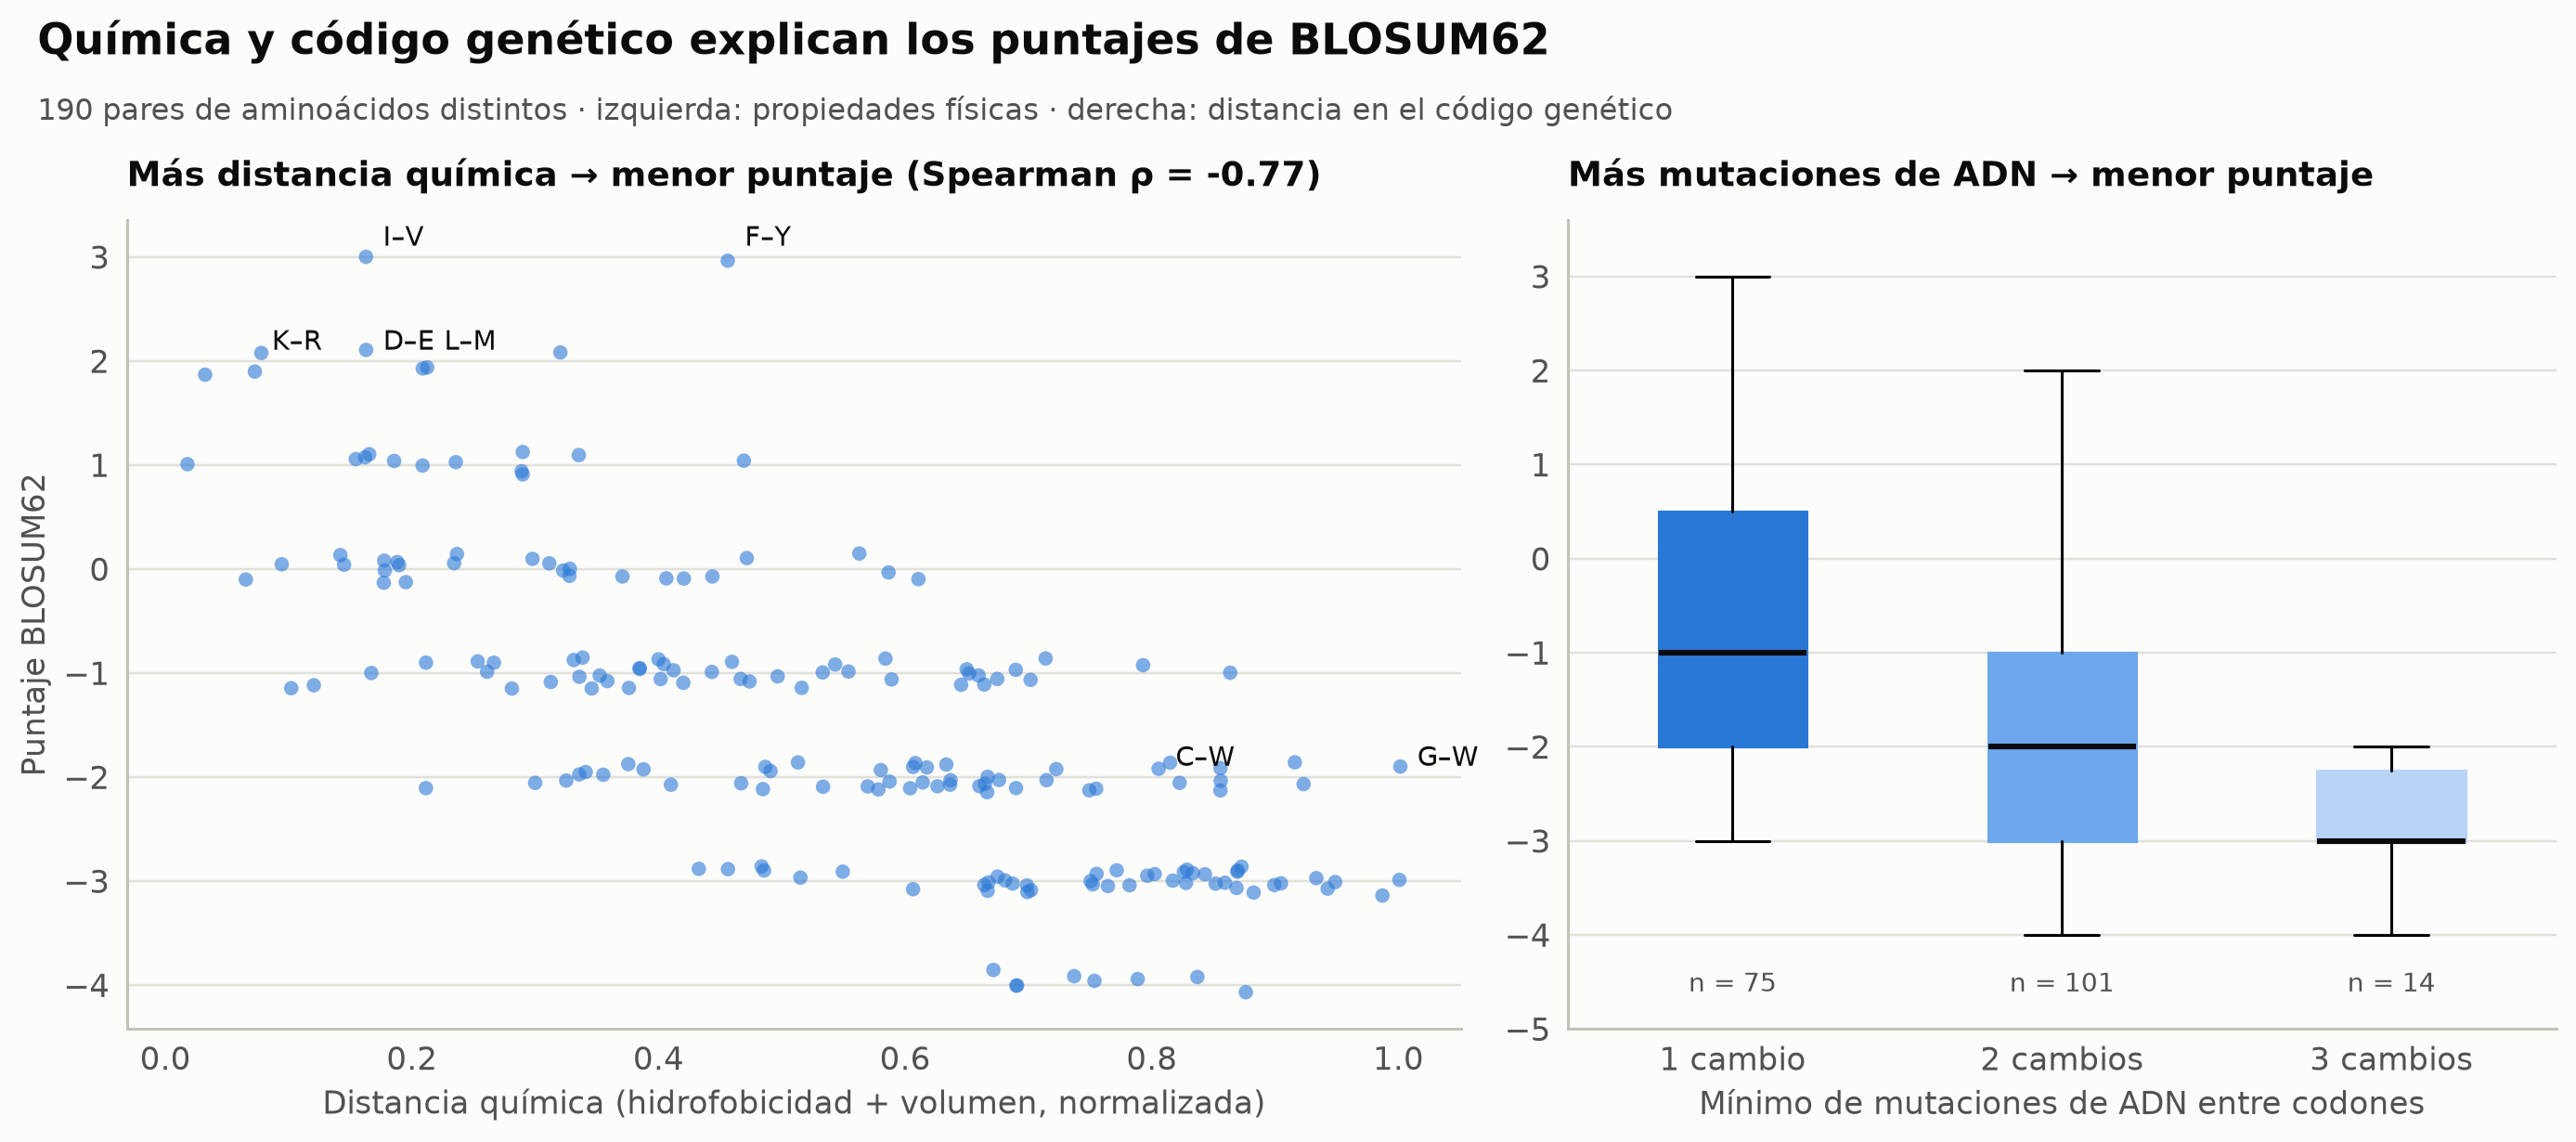

In [10]:
pairs = [(a, b) for i, a in enumerate(AA) for b in AA[i + 1:]]
dfp = pd.DataFrame({
    "pair": [a + b for a, b in pairs],
    "b62": [B62.loc[a, b] for a, b in pairs],
    "chem_dist": [np.hypot((kd[a] - kd[b]) / 9.0, (vol[a] - vol[b]) / 167.7) for a, b in pairs],
    "nt_changes": [min_nt_changes(a, b) for a, b in pairs],
})
rho = dfp[["b62", "chem_dist"]].corr(method="spearman").iloc[0, 1]

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.8), width_ratios=[1.35, 1])
ax = axes[0]
ax.scatter(dfp["chem_dist"], dfp["b62"] + np.random.default_rng(1).uniform(-0.15, 0.15, len(dfp)),
           s=26, color=ec.BLUE, alpha=0.6, edgecolor="none")
for p_ in ["IV", "LM", "DE", "KR", "FY", "GW", "CW"]:
    row = dfp[dfp["pair"].isin([p_, p_[::-1]])].iloc[0]
    ax.annotate(f"{p_[0]}–{p_[1]}", (row["chem_dist"], row["b62"]), xytext=(6, 4), textcoords="offset points",
                fontsize=9.5, color=ec.INK)
ax.set_xlabel("Distancia química (hidrofobicidad + volumen, normalizada)")
ax.set_ylabel("Puntaje BLOSUM62")
ax.set_title(f"Más distancia química → menor puntaje (Spearman ρ = {rho:.2f})", fontsize=12)

ax = axes[1]
data = [dfp.loc[dfp["nt_changes"] == k, "b62"] for k in (1, 2, 3)]
bp = ax.boxplot(data, positions=[1, 2, 3], widths=0.45, patch_artist=True, showfliers=False,
                medianprops=dict(color=ec.INK, lw=2))
for patch, c in zip(bp["boxes"], [ec.SEQ_BLUE[7], ec.SEQ_BLUE[4], ec.SEQ_BLUE[1]]):
    patch.set_facecolor(c); patch.set_edgecolor(c)
for k, d in zip((1, 2, 3), data):
    ax.text(k, -4.6, f"n = {len(d)}", ha="center", fontsize=9, color=ec.INK_2)
ax.set_ylim(-5, 3.6)
ax.set_xticks([1, 2, 3], ["1 cambio", "2 cambios", "3 cambios"])
ax.set_xlabel("Mínimo de mutaciones de ADN entre codones")
ax.set_title("Más mutaciones de ADN → menor puntaje", fontsize=12)
ec.fig_title(fig, "Química y código genético explican los puntajes de BLOSUM62",
             "190 pares de aminoácidos distintos · izquierda: propiedades físicas · derecha: distancia en el código genético")
plt.show()

> 🔎 **Qué observamos.** Las dos fuerzas actúan a la vez: los pares químicamente parecidos y los que están a una
> sola mutación de distancia tienen puntajes más altos. Nadie "programó" estas reglas en BLOSUM62: **emergieron** al
> contar qué sustituciones aceptó la evolución.

### 🖱️ Explore BLOSUM62 de forma interactiva

Pase el cursor sobre cada celda: verá las clases de ambos aminoácidos, el puntaje, y la razón **observado/esperado**
$q_{ab}/(p_ap_b) \approx 2^{s/2}$ (recuerde que el puntaje está en medios bits).

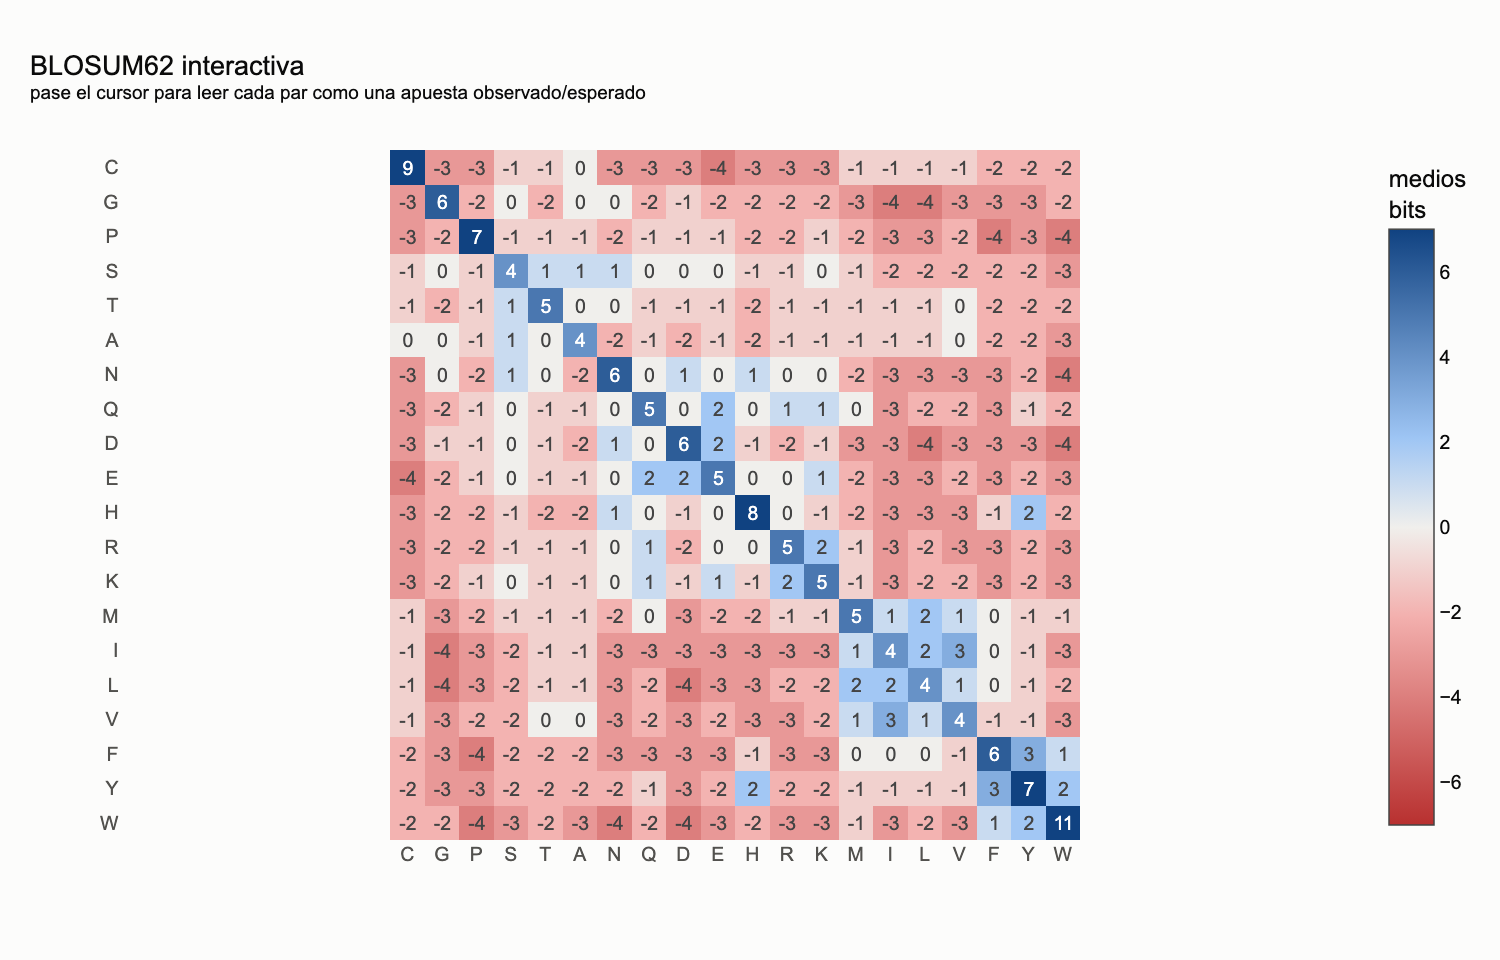

In [11]:
hover = [[f"<b>{a} ↔ {b}</b><br>{aa_class[a]} · {aa_class[b]}<br>puntaje = {B62.loc[a, b]:+.0f} medios bits"
          f"<br>observado/esperado ≈ 2^(s/2) = {2 ** (B62.loc[a, b] / 2):.2f}×"
          f"<br>mutaciones de ADN mínimas: {min_nt_changes(a, b) if a != b else 0}"
          for b in order] for a in order]
fig = go.Figure(go.Heatmap(z=M.values, x=order, y=order, text=M.values.astype(int), texttemplate="%{text}",
                           hovertext=hover, hoverinfo="text", zmid=0, zmin=-7, zmax=7,
                           colorscale=[[0, "#b8302f"], [0.35, "#f3b0ae"], [0.5, "#f0efec"],
                                       [0.65, "#9ec5f4"], [1, "#104281"]],
                           colorbar=dict(title="medios<br>bits")))
fig.update_layout(title=dict(text="BLOSUM62 interactiva<br><sup>pase el cursor para leer cada par como una apuesta"
                                  " observado/esperado</sup>"),
                  height=640, width=720, yaxis=dict(autorange="reversed", scaleanchor="x", showgrid=False),
                  xaxis=dict(showgrid=False),
                  margin=dict(t=100))
fig.show()

## 5. PAM: la evolución como cadena de Márkov

Antes que BLOSUM, Margaret Dayhoff y su equipo (1978) construyeron las matrices **PAM** (*Point Accepted
Mutation*) con otra idea. Observaron proteínas **muy parecidas** (más de 85 % de identidad) y contaron qué
sustituciones se habían **aceptado**. De ahí definieron la unidad **1 PAM**: el tiempo evolutivo en el que, en
promedio, **cambia el 1 %** de los aminoácidos.

¿Y para proteínas más lejanas? Piense en el juego del "teléfono descompuesto": un mensaje pasa de persona en
persona y en cada paso hay una pequeña probabilidad de que una palabra cambie. Si sabe qué pasa en **un** paso,
puede calcular qué pasa después de **250** pasos aplicando la misma regla una y otra vez. Esa es exactamente la
idea de una **cadena de Márkov**: el futuro solo depende del estado presente.

$$
M^{(1)}_{ab} = P(\text{el aminoácido } a \text{ se convierte en } b \text{ en 1 PAM})
\qquad\Longrightarrow\qquad
\boxed{\,M^{(n)} = \big(M^{(1)}\big)^{n}\,}
$$

| Símbolo | Significado |
|---|---|
| $M^{(1)}$ | matriz de transición de 20 × 20 para 1 PAM; cada fila suma 1 |
| $M^{(1)}_{aa}$ | probabilidad de que $a$ **no** cambie (≈ 0.99 en promedio) |
| $n$ | distancia evolutiva en PAMs |
| $M^{(n)}$ | probabilidad de pasar de $a$ a $b$ tras $n$ PAMs: **potencia** de la matriz |

La matriz de puntajes PAM$n$ es, otra vez, un log-odds: la probabilidad de terminar en $b$ partiendo de $a$, contra
la probabilidad de ver $b$ por azar:

$$
s_n(a,b) \;=\; 2\,\log_2 \frac{M^{(n)}_{ab}}{p_b}
$$

### Ejemplo a mano con dos estados

Reduzcamos el mundo a dos "aminoácidos": hidrofóbico (H) y polar (P). En un paso, H se queda H con probabilidad 0.9
y P se queda P con 0.8:

$$
M^{(1)} = \begin{pmatrix} 0.9 & 0.1 \\ 0.2 & 0.8 \end{pmatrix}
\qquad
M^{(2)} = M^{(1)} M^{(1)} = \begin{pmatrix} 0.9\cdot0.9 + 0.1\cdot0.2 & \cdots \\ \cdots & \cdots \end{pmatrix}
= \begin{pmatrix} 0.83 & 0.17 \\ 0.34 & 0.66 \end{pmatrix}
$$

El 0.83 suma dos caminos: H→H→H ($0.81$) y H→P→H ($0.02$). ¡La potencia de matrices cuenta automáticamente
**todos los caminos** posibles, incluidas las mutaciones que se revierten!

In [12]:
M1_toy = np.array([[0.9, 0.1], [0.2, 0.8]])
for n in [1, 2, 10, 100]:
    print(f"M^{n:<3d} =", np.linalg.matrix_power(M1_toy, n).round(3).tolist())
print("\nDistribución estacionaria (a donde converge cada fila): H = 2/3, P = 1/3")

M^1   = [[0.9, 0.1], [0.2, 0.8]]
M^2   = [[0.83, 0.17], [0.34, 0.66]]
M^10  = [[0.676, 0.324], [0.648, 0.352]]
M^100 = [[0.667, 0.333], [0.667, 0.333]]

Distribución estacionaria (a donde converge cada fila): H = 2/3, P = 1/3


> 🔎 **Qué observamos.** Con $n$ grande, **las dos filas se vuelven iguales**: después de mucho tiempo, el estado
> final ya no depende del inicial. La secuencia "olvidó" su origen y solo queda la composición de fondo. Para las
> proteínas esto significa que, a distancias enormes, **la homología se vuelve indetectable**.

### Una matriz PAM de 20 × 20

Dayhoff estimó $M^{(1)}$ contando sustituciones en árboles filogenéticos. Nosotros usaremos un atajo instructivo:
tomamos las frecuencias de pares implícitas en BLOSUM62, obtenemos su matriz de transición, y la "reescalamos" con
el **logaritmo de matriz** para que cambie exactamente el 1 % de los residuos. El resultado es una cadena de Márkov
**estilo PAM** (no la PAM original de Dayhoff, pero se construye y se comporta igual).

In [13]:
# Frecuencias de fondo estándar de los aminoácidos (Robinson & Robinson, 1991)
bg = dict(A=.07805, R=.05129, N=.04487, D=.05364, C=.01925, Q=.04264, E=.06295, G=.07377, H=.02199, I=.05142,
          L=.09019, K=.05744, M=.02243, F=.03856, P=.05203, S=.07120, T=.05841, W=.01330, Y=.03216, V=.06441)
p_bg = np.array([bg[a] for a in AA]); p_bg /= p_bg.sum()

def matrix_values(name):
    m = substitution_matrices.load(name)
    return np.array([[m[a, b] for b in AA] for a in AA], dtype=float)

def lambda_of(S, p=p_bg):
    """λ tal que Σ p_a p_b e^{λ s_ab} = 1 (escala natural de la matriz)."""
    return brentq(lambda l: (np.outer(p, p) * np.exp(l * S)).sum() - 1, 1e-3, 5)

# 1) frecuencias objetivo implícitas en BLOSUM62
S62 = matrix_values("BLOSUM62")
lam62 = lambda_of(S62)
q = np.outer(p_bg, p_bg) * np.exp(lam62 * S62)
q = (q + q.T) / 2; q /= q.sum()
pi = q.sum(axis=1)                               # composición de equilibrio
T = q / pi[:, None]                              # matriz de transición (cada fila suma 1)

# 2) matriz de tasas y reescalado a 1 % de cambio → PAM1
R = np.real(logm(T))
R /= -(pi * np.diag(R)).sum()                    # tasa total de cambio = 1 por unidad de tiempo
PAM1 = expm(0.01 * R)
PAM1 = np.clip(PAM1, 0, None); PAM1 /= PAM1.sum(axis=1, keepdims=True)

def pam(n):   return np.linalg.matrix_power(PAM1, n)
def pam_scores(n):
    return 2 * np.log2(np.maximum(pam(n), 1e-12) / pi[None, :])
def identity(n):
    return (pi * np.diag(pam(n))).sum()          # fracción esperada de residuos sin cambio

print(f"PAM1: identidad esperada = {identity(1):.4f}  (cambia el {100 * (1 - identity(1)):.2f} %)")
for n in [30, 80, 120, 250]:
    print(f"PAM{n:<3d}: identidad esperada = {identity(n):.1%}")

PAM1: identidad esperada = 0.9901  (cambia el 0.99 %)
PAM30 : identidad esperada = 74.8%
PAM80 : identidad esperada = 48.2%
PAM120: identidad esperada = 35.2%
PAM250: identidad esperada = 15.9%


🤔 **Antes de ejecutar, prediga:** si en 1 PAM cambia el 1 % de los residuos, ¿en 100 PAM cambia el 100 %?

La animación siguiente muestra la matriz de puntajes PAM$n$ (izquierda) y la identidad esperada entre las
secuencias (derecha) mientras la distancia evolutiva crece de 1 a 250 PAM.

![Animación: de PAM1 a PAM250, la matriz pierde contraste y la identidad cae hacia el nivel del azar](https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main/assets/modulo-03-alineamiento/3.3_pam_evolucion.gif)

*Animación: de PAM1 a PAM250, la matriz pierde contraste y la identidad cae hacia el nivel del azar*

In [14]:
ns = np.unique(np.round(np.logspace(0, np.log10(250), 44)).astype(int))
n_curve = np.arange(1, 401)
id_curve = np.array([identity(n) for n in n_curve])
id_random = (pi ** 2).sum()                                     # identidad entre dos secuencias al azar

fig, (axm, axc) = plt.subplots(1, 2, figsize=(11.5, 5), width_ratios=[1, 1.15])
im = axm.imshow(np.clip(pam_scores(1), -8, 8), cmap=ec.CMAP_DIV.reversed(), vmin=-8, vmax=8)
axm.set_xticks(range(20), list(AA), fontsize=7.5); axm.set_yticks(range(20), list(AA), fontsize=7.5)
axm.tick_params(length=0); axm.grid(False)
for s in axm.spines.values(): s.set_visible(False)
ttl = axm.set_title("PAM1", loc="left", fontsize=13)

axc.plot(n_curve, id_curve, color=ec.BLUE, lw=2)
axc.plot(n_curve, 1 - n_curve / 100, color=ec.ORANGE, lw=1.4, ls="--")
axc.text(12, 0.12, "si el cambio fuera\nlineal (1 % por PAM)", color=ec.INK_2, fontsize=9)
axc.axhline(id_random, color=ec.BASELINE, lw=1)
axc.text(400, id_random + 0.015, f"azar: {id_random:.1%}", ha="right", color=ec.INK_2, fontsize=9)
dot, = axc.plot([], [], "o", color=ec.BLUE, markersize=9, markeredgecolor=ec.SURFACE, markeredgewidth=2)
lab = axc.text(0, 0, "", fontsize=10.5, fontweight="bold", color=ec.INK)
axc.set_xlim(0, 400); axc.set_ylim(0, 1.02)
axc.set_xlabel("Distancia evolutiva (PAM)"); axc.set_ylabel("Identidad esperada")
axc.set_title("Identidad entre ancestro y descendiente", loc="left", fontsize=13)

def update(f):
    n = ns[f]
    im.set_data(np.clip(pam_scores(n), -8, 8))
    ttl.set_text(f"Puntajes PAM{n}  (medios bits)")
    dot.set_data([n], [identity(n)])
    lab.set_position((n + 8, identity(n) + 0.03)); lab.set_text(f"{identity(n):.0%}")
    return im, dot, lab

ec.animate(fig, update, frames=len(ns), interval=160, name="3.3_pam_evolucion")

▶️ Ejecute esta celda para ver la animación con controles (la vista previa GIF está en la celda de texto de arriba).

> 🔎 **Qué observamos.**
> * La identidad **no** cae en línea recta: en 100 PAM todavía queda cerca del 40 % de identidad. Esto se debe a las
>   **mutaciones múltiples**: una posición puede cambiar dos veces, o cambiar y volver, y la potencia de matrices lo
>   cuenta automáticamente.
> * Hacia PAM250 la identidad se acerca a un ~15–20 %, apenas por encima del azar (~6 %). Esa es la famosa
>   **zona de penumbra** (*twilight zone*): a esas distancias, la identidad sola ya no distingue homólogos de
>   secuencias no relacionadas, y la matriz adecuada se vuelve decisiva.
> * La matriz pierde contraste: a gran distancia, los puntajes se acercan a cero porque cada par ya "casi" es azar.

## 6. ¿Cuánta información trae una matriz? Entropía relativa

Cada matriz está "afinada" para una distancia evolutiva. Una forma de medirlo es preguntar: **en promedio, cuánta
evidencia aporta cada columna** de un alineamiento verdadero. Esa es la **entropía relativa**:

$$
H \;=\; \sum_{a,b} q_{ab}\; \underbrace{\log_2 \frac{q_{ab}}{p_a\,p_b}}_{\text{puntaje en bits}}
\qquad [\text{bits por posición}]
$$

| Símbolo | Significado |
|---|---|
| $q_{ab}$ | frecuencia del par en alineamientos verdaderos (ponderamos por lo que realmente se ve) |
| $\log_2 \frac{q_{ab}}{p_ap_b}$ | evidencia que aporta ese par, en bits |
| $H$ | evidencia promedio por columna; $H = 0$ significa "indistinguible del azar" |

Para una matriz dada podemos recuperar $q_{ab}$ con $q_{ab} = p_a p_b\, e^{\lambda s_{ab}}$, donde $\lambda$ es el
número que hace que esas frecuencias sumen 1.

**¿Para qué sirve $H$?** Para saber **cuánto debe medir un alineamiento** para ser convincente. Si necesitamos,
digamos, ~30 bits para distinguir un homólogo en una base de datos grande, con $H = 0.7$ bits/posición bastan unas
40 columnas; con $H = 0.3$ hacen falta 100.

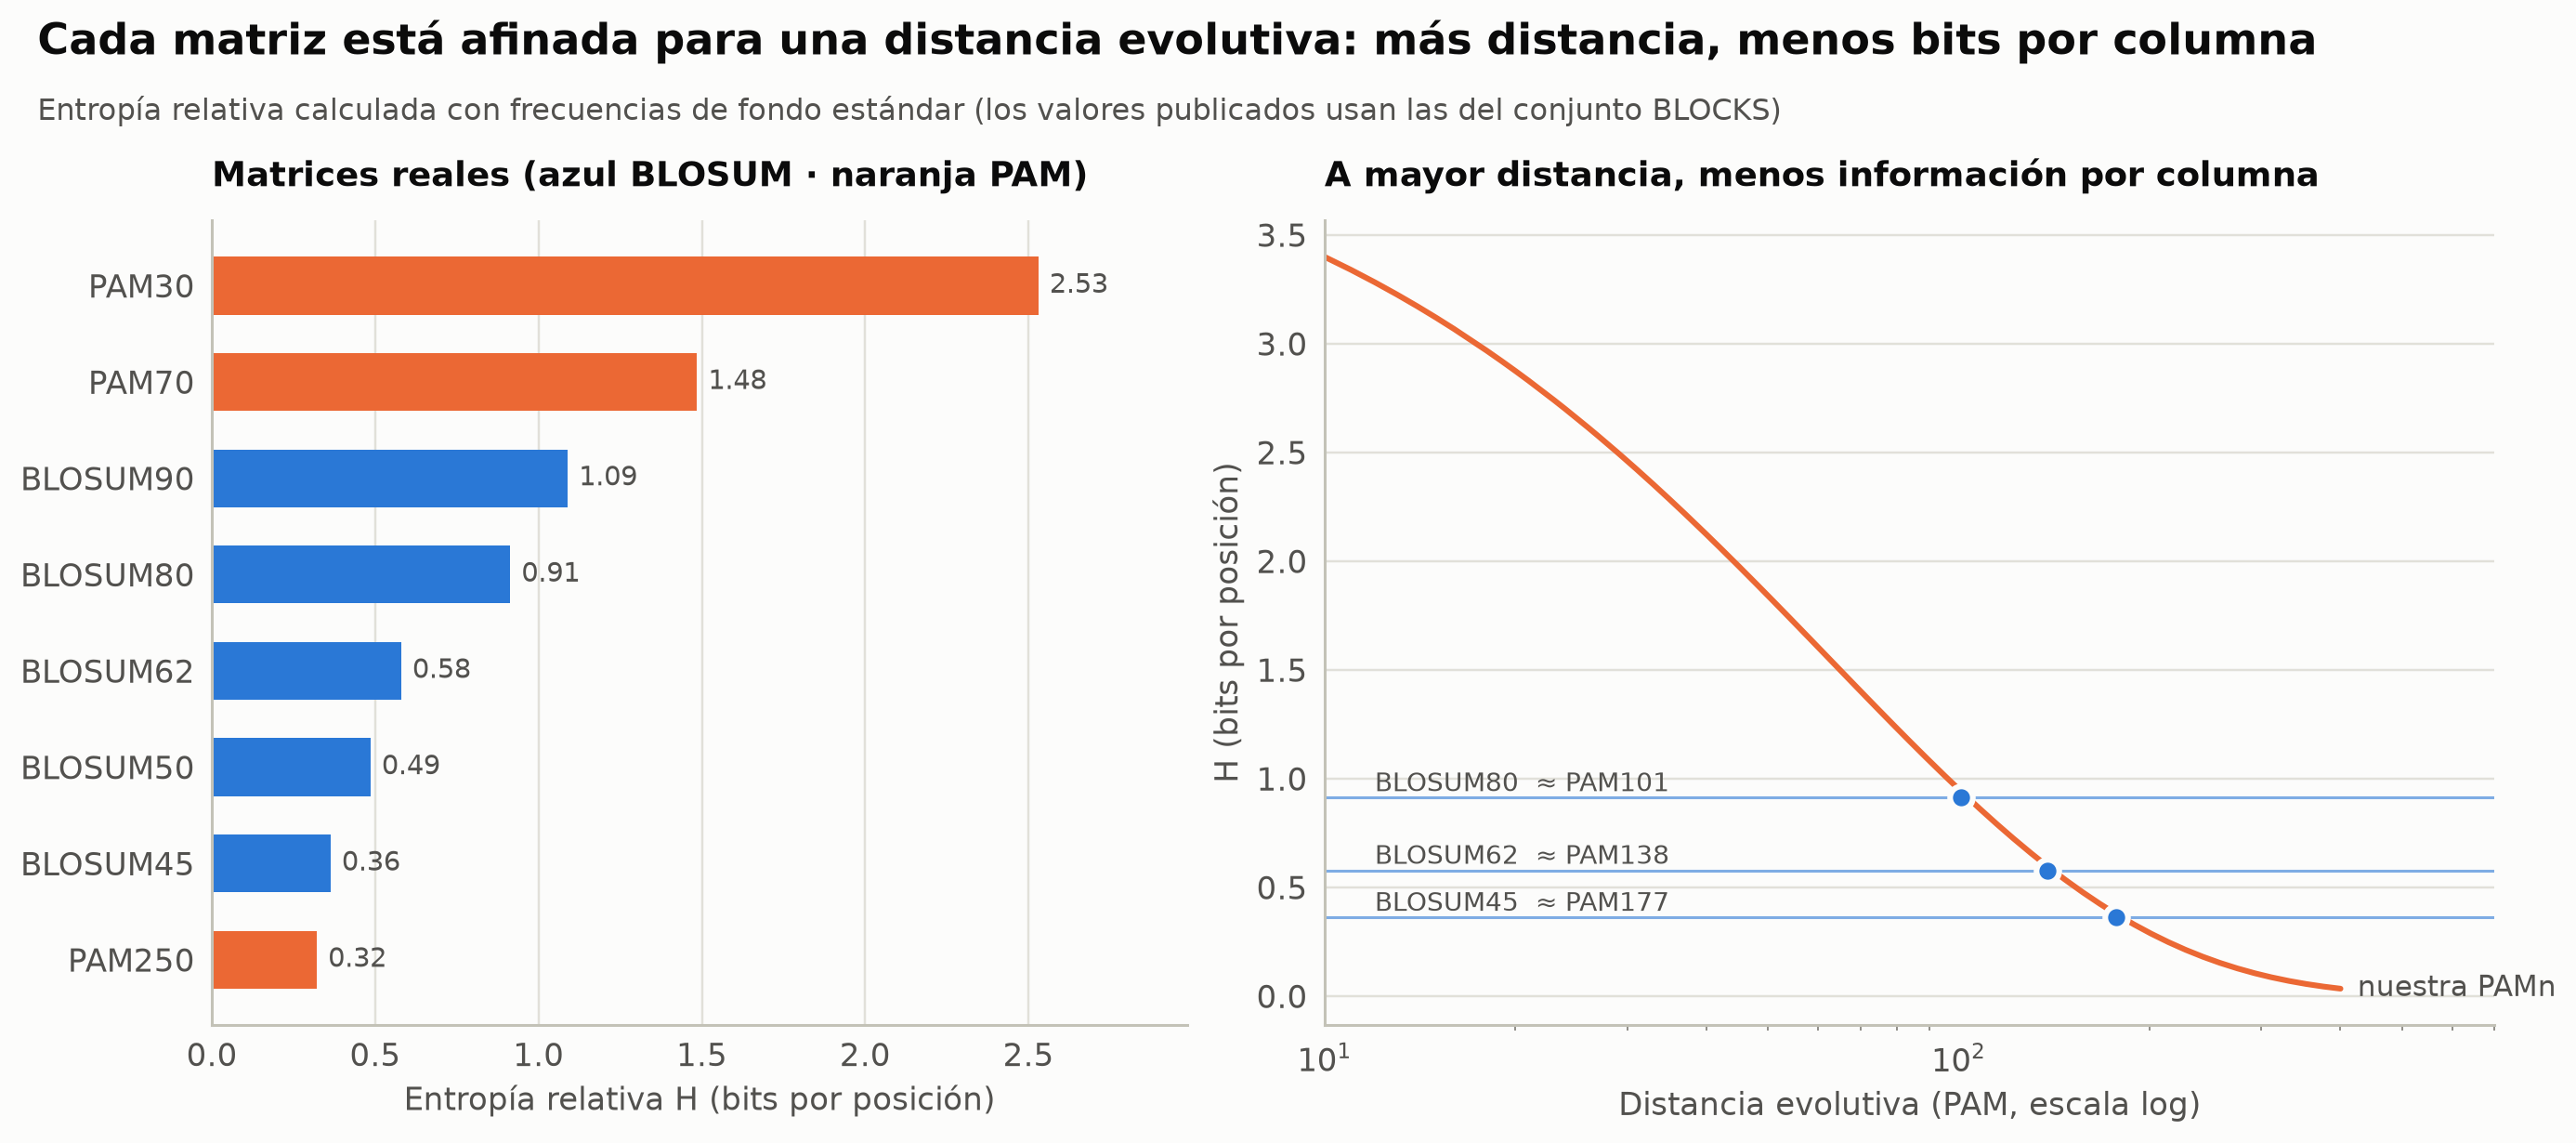

In [15]:
def relative_entropy_bits(S, p=p_bg):
    lam = lambda_of(S, p)
    qq = np.outer(p, p) * np.exp(lam * S)
    return (qq * lam * S).sum() / np.log(2)

real = ["PAM30", "PAM70", "BLOSUM90", "BLOSUM80", "BLOSUM62", "BLOSUM50", "BLOSUM45", "PAM250"]
H_real = pd.Series({n: relative_entropy_bits(matrix_values(n)) for n in real}).sort_values(ascending=False)

n_grid = np.unique(np.round(np.logspace(np.log10(10), np.log10(400), 60)).astype(int))
H_pam = []
for n in n_grid:
    qq = pi[:, None] * pam(n)                             # frecuencias objetivo q_ab de nuestra PAMn
    H_pam.append((qq * np.log2(pam(n) / pi[None, :])).sum())

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.8), width_ratios=[1, 1.2])
ax = axes[0]
colors = [ec.BLUE if k.startswith("BLOSUM") else ec.ORANGE for k in H_real.index]
bars = ax.barh(H_real.index[::-1], H_real.values[::-1], color=colors[::-1], height=0.6)
ax.bar_label(bars, fmt="%.2f", padding=4, color=ec.INK_2, fontsize=9.5)
ax.set_xlabel("Entropía relativa H (bits por posición)")
ax.grid(axis="y", visible=False); ax.grid(axis="x", visible=True)
ax.set_xlim(0, H_real.max() * 1.18)
ax.set_title("Matrices reales (azul BLOSUM · naranja PAM)", fontsize=12)

ax = axes[1]
ax.plot(n_grid, H_pam, color=ec.ORANGE, lw=2)
ec.label_end(ax, n_grid[-1], H_pam[-1], "nuestra PAMn")
H_pam = np.array(H_pam)
equiv = {}
for name in ["BLOSUM80", "BLOSUM62", "BLOSUM45"]:
    h = H_real[name]
    n_eq = int(n_grid[np.argmin(np.abs(H_pam - h))])        # PAMn con la misma información
    equiv[name] = n_eq
    ax.axhline(h, color=ec.BLUE, lw=1, alpha=0.6)
    ax.plot([n_eq], [h], "o", color=ec.BLUE, markersize=8, markeredgecolor=ec.SURFACE, markeredgewidth=2)
    ax.text(12, h + 0.03, f"{name}  ≈ PAM{n_eq}", color=ec.INK_2, fontsize=9)
ax.set_xscale("log")
ax.set_xlabel("Distancia evolutiva (PAM, escala log)"); ax.set_ylabel("H (bits por posición)")
ax.set_xlim(10, 700)
ax.set_title("A mayor distancia, menos información por columna", fontsize=12)
ec.fig_title(fig, "Cada matriz está afinada para una distancia evolutiva: más distancia, menos bits por columna",
             "Entropía relativa calculada con frecuencias de fondo estándar (los valores publicados usan las del conjunto BLOCKS)")
plt.show()

> 🔎 **Qué observamos.** Las matrices "cercanas" (PAM30, BLOSUM90) aportan mucha información por columna pero solo
> son útiles para secuencias muy parecidas; las "lejanas" (PAM250, BLOSUM45) aportan poca información por columna
> pero son más tolerantes a los cambios, y funcionan para parientes distantes. PAM250 y BLOSUM45 tienen una
> entropía parecida: están afinadas para distancias comparables. En el panel derecho, cada punto azul marca la
> distancia PAM de **nuestra** cadena de Márkov con la misma información que una BLOSUM; la literatura suele citar
> equivalencias parecidas (BLOSUM80 ≈ PAM120, BLOSUM45 ≈ PAM250). Los números exactos dependen de las frecuencias
> de fondo y del modelo, así que tómelos como guía, no como constantes.

**Guía práctica para elegir matriz:**

| Situación | Matriz sugerida |
|---|---|
| Péptidos cortos o secuencias casi idénticas | PAM30, PAM70, BLOSUM80–90 |
| Búsqueda general (valor por defecto de BLASTP) | **BLOSUM62** |
| Homólogos lejanos, zona de penumbra | BLOSUM45, PAM250 |

### 🖱️ Compare matrices de forma interactiva

Use el menú para cambiar de matriz. Observe cómo cambian el contraste y el valor de la diagonal.

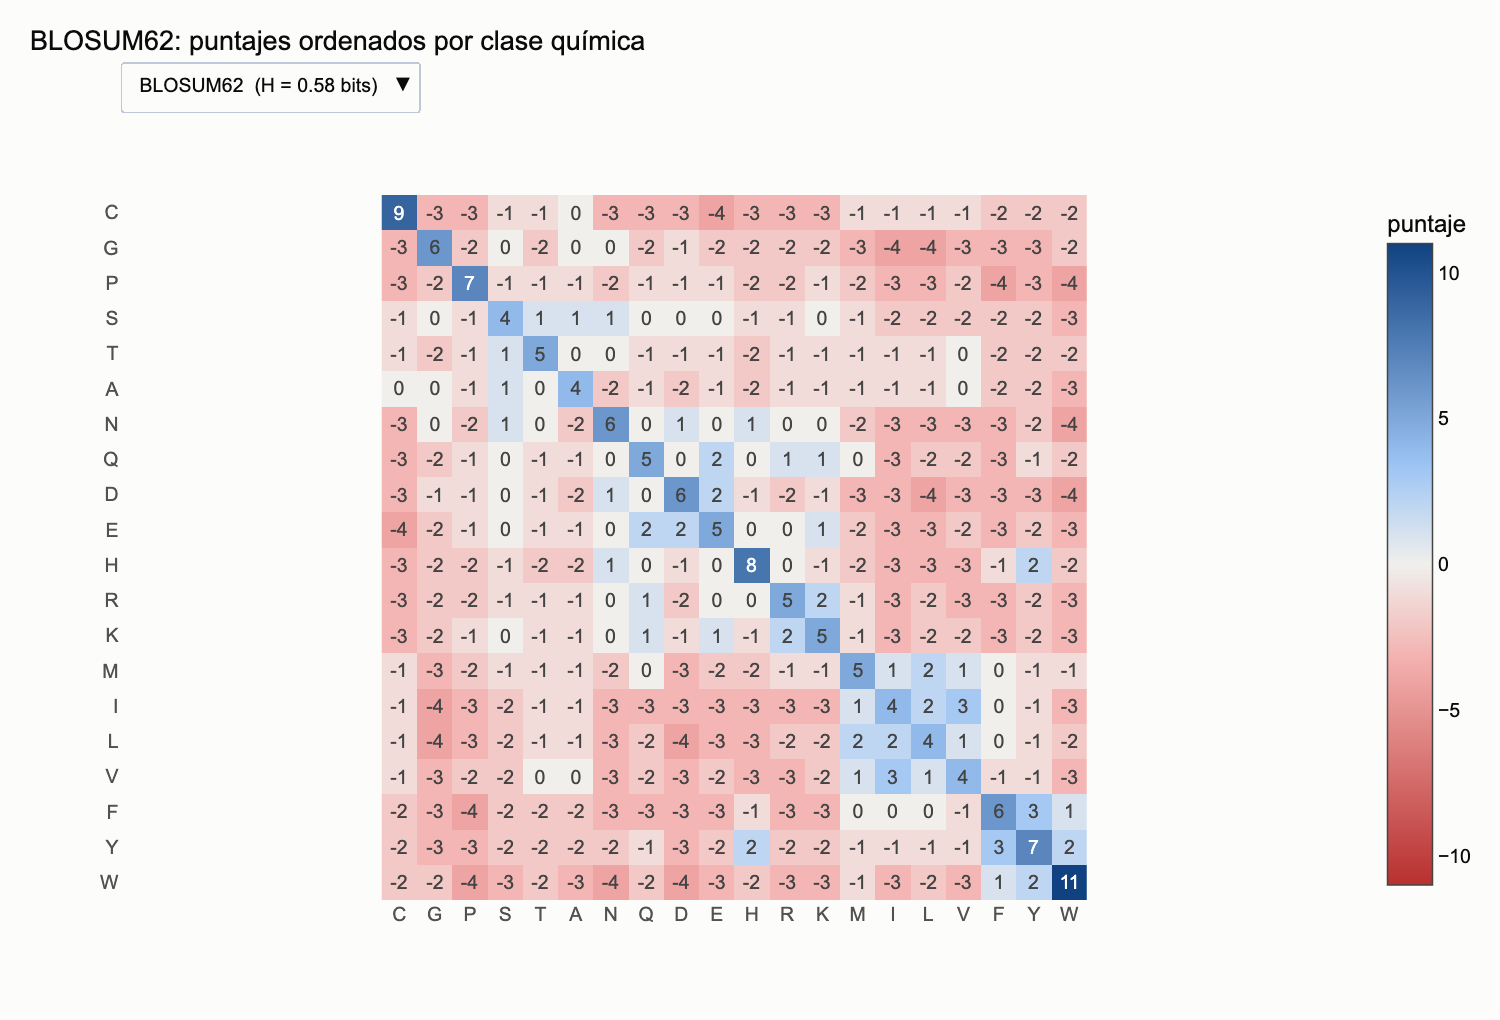

In [16]:
choices = ["BLOSUM45", "BLOSUM62", "BLOSUM80", "PAM30", "PAM250"]
fig = go.Figure()
for k, name in enumerate(choices):
    m = substitution_matrices.load(name)
    Z = np.array([[m[a, b] for b in order] for a in order])
    fig.add_trace(go.Heatmap(z=Z, x=order, y=order, zmid=0, visible=(k == 1), text=Z.astype(int),
                             texttemplate="%{text}",
                             colorscale=[[0, "#b8302f"], [0.35, "#f3b0ae"], [0.5, "#f0efec"],
                                         [0.65, "#9ec5f4"], [1, "#104281"]],
                             hovertemplate=f"<b>{name}</b><br>%{{y}} ↔ %{{x}}: %{{z}}<extra></extra>",
                             colorbar=dict(title="puntaje")))
buttons = [dict(label=f"{name}  (H = {relative_entropy_bits(matrix_values(name)):.2f} bits)", method="update",
                args=[{"visible": [j == k for j in range(len(choices))]},
                      {"title.text": f"{name}: puntajes ordenados por clase química"}])
           for k, name in enumerate(choices)]
fig.update_layout(updatemenus=[dict(buttons=buttons, active=1, x=0, xanchor="left", y=1.12, yanchor="bottom")],
                  title=dict(text="BLOSUM62: puntajes ordenados por clase química", y=0.97),
                  height=680, width=740, yaxis=dict(autorange="reversed", scaleanchor="x", showgrid=False),
                  xaxis=dict(showgrid=False), margin=dict(t=130))
fig.show()

> ✅ **Compruebe su comprensión.**
> 1. ¿Por qué W–W vale +11 en BLOSUM62 pero +17 en PAM250? *(Pista: PAM250 usa otra escala — tercios de bit en
>    Biopython — y otras frecuencias; compare siempre dentro de la misma matriz.)*
> 2. ¿Qué matriz usaría para buscar un péptido de 12 aminoácidos casi idéntico en una base de datos?

## 7. Un vistazo al ADN: transiciones y transversiones

Para nucleótidos la historia es más simple, pero no trivial. Las mutaciones de ADN son de dos tipos:

* **Transiciones**: purina ↔ purina (A ↔ G) o pirimidina ↔ pirimidina (C ↔ T). Las bases tienen forma parecida.
* **Transversiones**: purina ↔ pirimidina (por ejemplo A ↔ C). Cambian el tamaño del anillo.

Aunque hay el doble de transversiones posibles (8 frente a 4), en genomas reales las transiciones suelen ser
**más frecuentes**. Su razón se llama $\kappa$ (kappa). Una matriz log-odds que tenga esto en cuenta castiga menos
una transición que una transversión. Las herramientas populares a menudo usan algo más simple: BLASTN, por
defecto, puntúa **+2** por coincidencia y **−3** por desajuste, sin distinguir tipos.

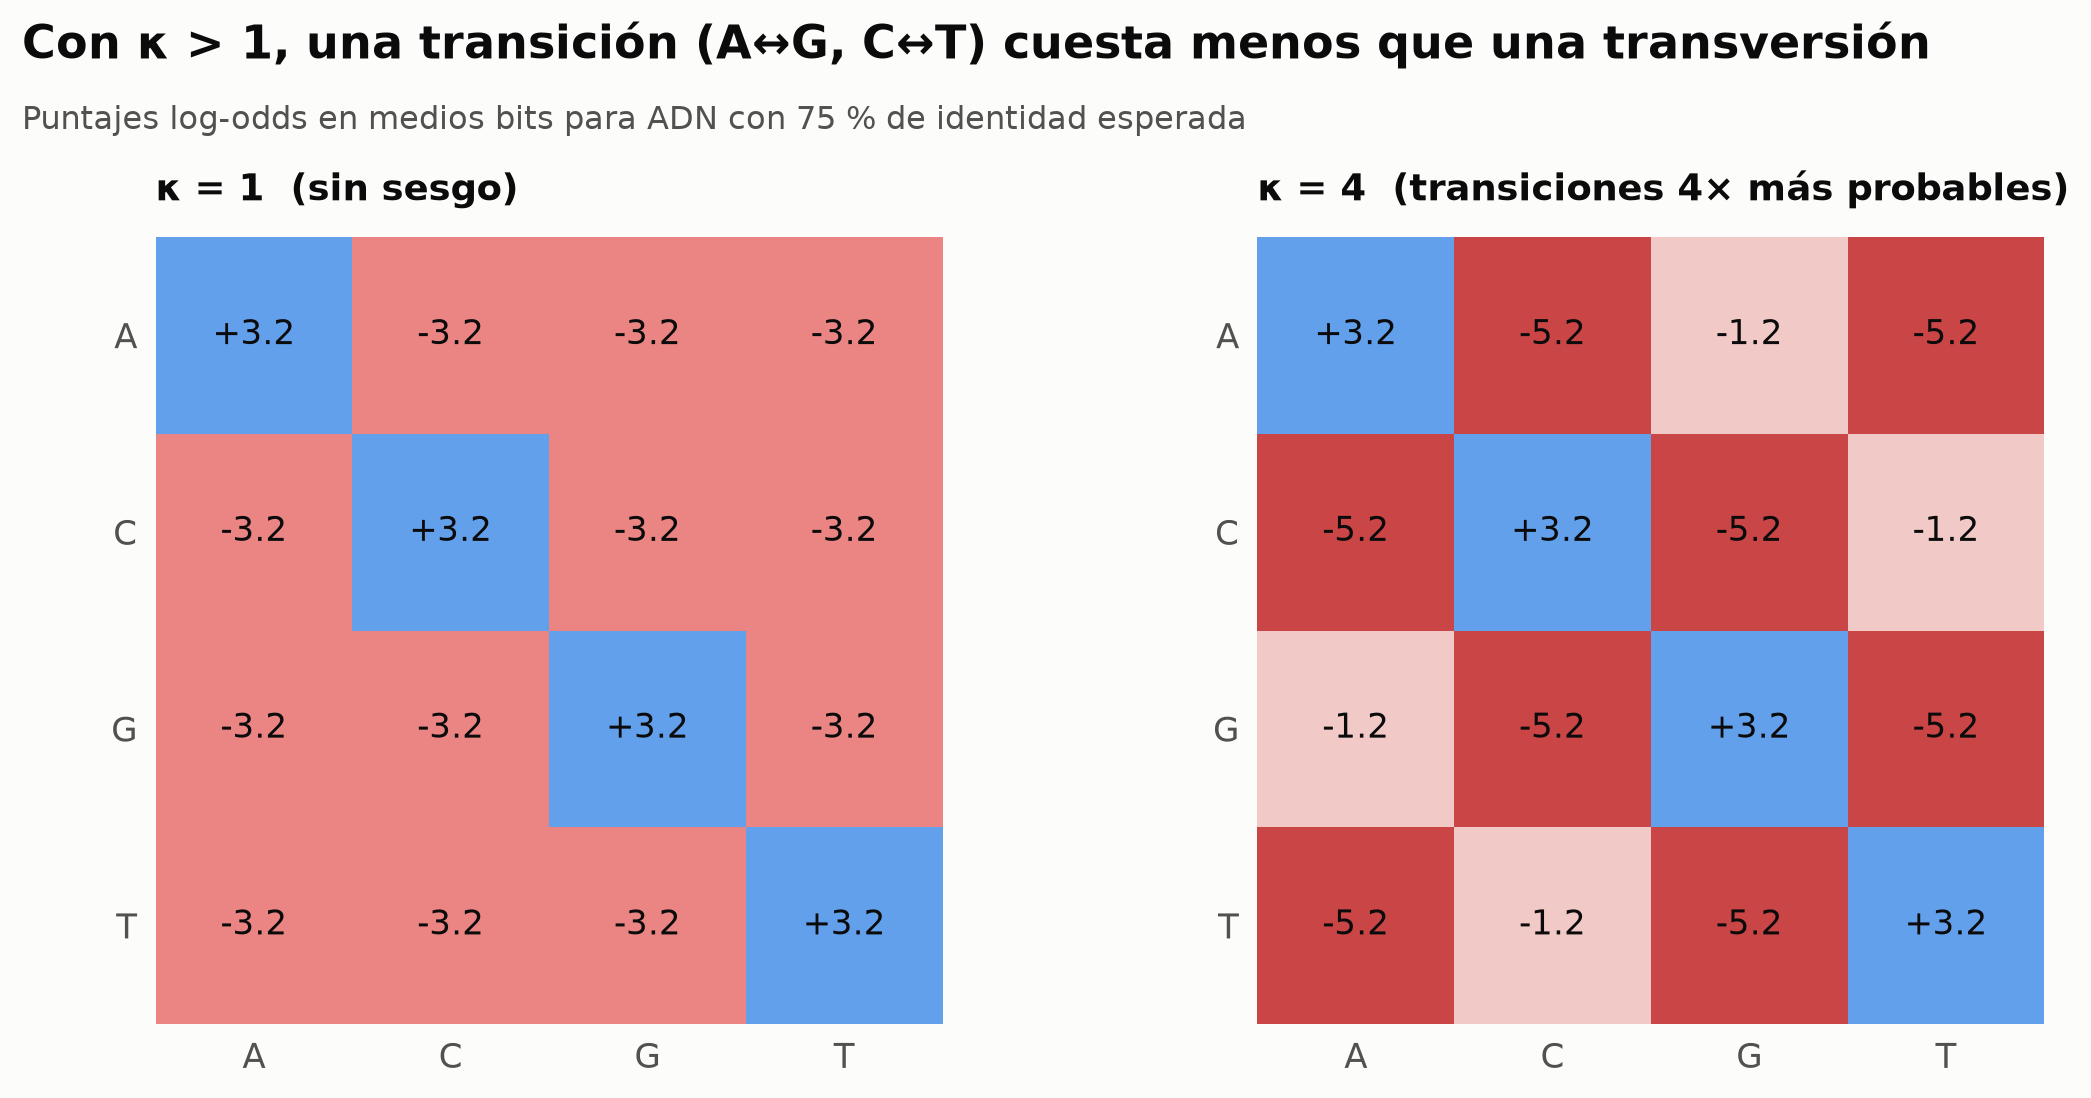

In [17]:
def dna_logodds(kappa=2.0, identity_frac=0.75):
    """Matriz log-odds (medios bits) para ADN con razón transición/transversión kappa."""
    bases = "ACGT"
    transitions = {("A", "G"), ("G", "A"), ("C", "T"), ("T", "C")}
    mism = 1 - identity_frac
    ts = mism * kappa / (kappa + 2)            # probabilidad total de transición
    tv = mism * 2 / (kappa + 2) / 2            # probabilidad de cada una de las 2 transversiones
    P = np.array([[identity_frac if a == b else (ts if (a, b) in transitions else tv) for b in bases]
                  for a in bases])
    return pd.DataFrame(2 * np.log2(P / 0.25), index=list(bases), columns=list(bases))

fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))
for ax, kappa in zip(axes, [1.0, 4.0]):
    D = dna_logodds(kappa)
    ax.imshow(D.values, cmap=ec.CMAP_DIV.reversed(), vmin=-6, vmax=6)
    for i in range(4):
        for j in range(4):
            ax.text(j, i, f"{D.values[i, j]:+.1f}", ha="center", va="center", fontsize=11,
                    color=ec.INK)
    ax.set_xticks(range(4), list("ACGT")); ax.set_yticks(range(4), list("ACGT"))
    ax.tick_params(length=0); ax.grid(False)
    for s in ax.spines.values(): s.set_visible(False)
    ax.set_title(f"κ = {kappa:g}" + ("  (sin sesgo)" if kappa == 1 else "  (transiciones 4× más probables)"),
                 fontsize=12)
ec.fig_title(fig, "Con κ > 1, una transición (A↔G, C↔T) cuesta menos que una transversión",
             "Puntajes log-odds en medios bits para ADN con 75 % de identidad esperada")
plt.show()

## 8. Huecos: lineales contra afines

Los alineamientos no solo tienen sustituciones: también **inserciones y deleciones** (indels), que se representan
con huecos (`-`). ¿Cuánto debe costar un hueco?

Piense en una mudanza: lo caro es **empezar** (alquilar el camión, cargarlo); una vez en marcha, llevar una caja más
cuesta poco. Con los indels pasa algo parecido: un solo evento biológico (por ejemplo, un error de la polimerasa
que salta varias bases, o la pérdida de un exón) puede crear un hueco **largo** de una sola vez. Tres huecos de una
posición requieren **tres** eventos independientes; un hueco de tres posiciones, solo **uno**.

**Penalización lineal** (cada posición cuesta lo mismo):

$$
W_{\text{lineal}}(k) \;=\; g \cdot k
$$

**Penalización afín** (abrir cuesta mucho, extender poco):

$$
\boxed{\,W_{\text{afín}}(k) \;=\; g_{\text{abrir}} \;+\; g_{\text{ext}}\cdot(k-1)\,}
$$

| Símbolo | Significado |
|---|---|
| $k$ | longitud del hueco (número de posiciones con `-`) |
| $g$ | costo por posición en el modelo lineal |
| $g_{\text{abrir}}$ | costo de **abrir** el hueco (incluye su primera posición) |
| $g_{\text{ext}}$ | costo de cada posición **adicional** |

> ⚠️ **Convenciones.** BLAST expresa el costo como $a + b\,k$ ("existencia" $a$ = 11, "extensión" $b$ = 1 con
> BLOSUM62), es decir, un hueco de 1 cuesta 12. En nuestra notación eso es $g_{\text{abrir}} = 12$,
> $g_{\text{ext}} = 1$. En Biopython: `open_gap_score = -12`, `extend_gap_score = -1`. Siempre revise qué convención
> usa cada programa.

### Ejemplo a mano

Con $g_{\text{abrir}} = 12$ y $g_{\text{ext}} = 1$ (afín) frente a $g = 4$ (lineal):

| Situación | Lineal ($g = 4$) | Afín (12, 1) |
|---|---|---|
| 1 hueco de 3 posiciones | $4 \times 3 = 12$ | $12 + 1 \times 2 = 14$ |
| 3 huecos de 1 posición | $3 \times 4 = 12$ | $3 \times 12 = 36$ |

¡En el modelo lineal ambas situaciones cuestan lo mismo! El modelo afín prefiere, con razón, **un** evento largo
sobre tres eventos cortos dispersos.

In [18]:
def gap_linear(k, g=4):       return g * k
def gap_affine(k, g_open=12, g_ext=1):
    return np.where(k > 0, g_open + g_ext * (k - 1), 0)

print("Un hueco de 3   → lineal:", gap_linear(3), "· afín:", int(gap_affine(3)))
print("Tres huecos de 1 → lineal:", 3 * gap_linear(1), "· afín:", 3 * int(gap_affine(1)))

# El mismo par de secuencias con los dos modelos de huecos
a, b = "MKVLAAGIVGSTWYDEK", "MKVLAGSTWYDEK"                   # a b le faltan 4 residuos
for label, go_, ge_ in [("lineal (4 por posición)", -4, -4), ("afín (abrir 12, extender 1)", -12, -1)]:
    al = PairwiseAligner(mode="global", substitution_matrix=blosum62,
                         open_gap_score=go_, extend_gap_score=ge_, end_gap_score=0)
    aln = al.align(a, b)[0]
    print(f"\n{label}: puntaje = {aln.score}\n{aln}")

Un hueco de 3   → lineal: 12 · afín: 14
Tres huecos de 1 → lineal: 12 · afín: 36

lineal (4 por posición): puntaje = 55.0
target            0 MKVLAAGIVGSTWYDEK 17
                  0 |||||-|---||||||| 17
query             0 MKVLA-G---STWYDEK 13


afín (abrir 12, extender 1): puntaje = 56.0
target            0 MKVLAAGIVGSTWYDEK 17
                  0 |||||----|||||||| 17
query             0 MKVLA----GSTWYDEK 13



> 🔎 **Qué observamos.** Con las **mismas** secuencias y la **misma** matriz, el modelo lineal parte el hueco en dos
> pedazos (le da igual uno largo que varios cortos), mientras que el modelo afín agrupa los cuatro residuos faltantes
> en **un solo** hueco: la explicación biológica más sencilla, un único evento de deleción.

La animación muestra cómo crece el costo de un único hueco al alargarse, con ambos modelos.

![Animación: un hueco que se alarga; el costo lineal crece rápido, el afín se paga casi todo al abrir](https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main/assets/modulo-03-alineamiento/3.3_hueco_crece.gif)

*Animación: un hueco que se alarga; el costo lineal crece rápido, el afín se paga casi todo al abrir*

In [19]:
ks = np.arange(0, 13)
top = "MKVLAAGIVGSTWYDEK"
fig, (axs, axc) = plt.subplots(2, 1, figsize=(10, 5.8), height_ratios=[1, 2.2])
axs.axis("off"); axs.set_xlim(0, 1); axs.set_ylim(0, 1)
t1 = axs.text(0.02, 0.68, "", family="DejaVu Sans Mono", fontsize=15, color=ec.INK)
t2 = axs.text(0.02, 0.22, "", family="DejaVu Sans Mono", fontsize=15, color=ec.INK)
axs.set_title("Un hueco que se alarga dentro de un alineamiento", loc="left", fontsize=13)

axc.plot(ks, gap_linear(ks), color=ec.ORANGE, lw=2)
axc.plot(ks, gap_affine(ks), color=ec.BLUE, lw=2)
ec.label_end(axc, ks[-1], gap_linear(ks[-1]), "lineal (4 por posición)")
ec.label_end(axc, ks[-1], gap_affine(ks[-1]), "afín (abrir 12, extender 1)")
d1, = axc.plot([], [], "o", color=ec.ORANGE, markersize=10, markeredgecolor=ec.SURFACE, markeredgewidth=2)
d2, = axc.plot([], [], "o", color=ec.BLUE, markersize=10, markeredgecolor=ec.SURFACE, markeredgewidth=2)
txt = axc.text(0.3, 44, "", fontsize=11, color=ec.INK)
axc.set_xlim(0, 17); axc.set_ylim(0, 52)
axc.set_xlabel("Longitud del hueco k"); axc.set_ylabel("Penalización W(k)")

def update(f):
    k = ks[f]
    bottom = top[:5] + "-" * k + top[5 + k:] if k else top
    t1.set_text(top); t2.set_text(bottom)
    d1.set_data([k], [gap_linear(k)]); d2.set_data([k], [gap_affine(k)])
    txt.set_text(f"k = {k}:  lineal = {gap_linear(k)}  ·  afín = {int(gap_affine(k))}")
    return t1, t2, d1, d2, txt

ec.animate(fig, update, frames=len(ks), interval=650, name="3.3_hueco_crece")

▶️ Ejecute esta celda para ver la animación con controles (la vista previa GIF está en la celda de texto de arriba).

> 🔎 **Qué observamos.** Para huecos cortos (1–2 posiciones) el modelo afín es **más severo** que el lineal: abrir un
> hueco debe estar muy justificado. Para huecos largos es **mucho más indulgente**: una vez aceptado que ocurrió un
> indel, su longitud importa poco.

### ¿Cómo se calcula un alineamiento con huecos afines? (idea de Gotoh)

Con huecos afines, el costo de una columna depende de si **ya estábamos** dentro de un hueco. Gotoh (1982) resolvió
esto usando **tres tablas** en lugar de una: $M$ (terminar en un par alineado), $X$ (terminar con un hueco en una
secuencia) e $Y$ (hueco en la otra):

$$
\begin{aligned}
M_{i,j} &= s(x_i, y_j) + \max\{M_{i-1,j-1},\; X_{i-1,j-1},\; Y_{i-1,j-1}\} \\
X_{i,j} &= \max\{M_{i-1,j} - g_{\text{abrir}},\;\; X_{i-1,j} - g_{\text{ext}}\} \\
Y_{i,j} &= \max\{M_{i,j-1} - g_{\text{abrir}},\;\; Y_{i,j-1} - g_{\text{ext}}\}
\end{aligned}
$$

Pasar de $M$ a $X$ cuesta **abrir**; quedarse en $X$ cuesta **extender**. El algoritmo sigue siendo
$O(n\,m)$, como el de la Lección 3.2. (No se preocupe por memorizarlo: lo importante es la idea de "recordar si
estoy dentro de un hueco".)

## 9. 🧪 Experimento: ¿qué matriz encuentra a la mioglobina?

Llegó la prueba de fuego. Vamos a alinear (alineamiento **local**, como hace BLAST) tres pares de globinas con seis
matrices distintas, cada una con los huecos que BLAST usa por defecto para ella.

**¿Cómo comparamos puntajes de matrices con escalas distintas?** No podemos comparar "puntaje 120 con BLOSUM62"
con "puntaje 300 con PAM30". Usaremos un truco estadístico muy robusto: **barajar**. Para cada alineamiento,
barajamos 200 veces una de las secuencias (misma composición, orden destruido) y medimos el puntaje de esos
alineamientos "falsos". Luego calculamos el **puntaje z**, que ya conoce de la Lección 0.1:

$$
z \;=\; \frac{S_{\text{real}} - \overline{S}_{\text{barajado}}}{\sigma_{\text{barajado}}}
$$

| Símbolo | Significado |
|---|---|
| $S_{\text{real}}$ | puntaje del alineamiento de las secuencias verdaderas |
| $\overline{S}_{\text{barajado}}$, $\sigma_{\text{barajado}}$ | media y desviación estándar de los puntajes con secuencias barajadas |
| $z$ | cuántas desviaciones estándar se separa la señal real del ruido; **más alto = homología más evidente** |

🤔 **Antes de ejecutar, prediga:** para el par más lejano (hemoglobina β vs. mioglobina, ~25–30 % de identidad), ¿qué
matriz dará el $z$ más alto: PAM30 o BLOSUM45?

In [20]:
gap_defaults = {"BLOSUM45": (14, 2), "BLOSUM62": (11, 1), "BLOSUM80": (10, 1),
                "PAM30": (9, 1), "PAM70": (10, 1), "PAM250": (14, 2)}   # convención BLAST: a + b·k
pairs_exp = [("HBB_HUMAN", "HBB1_MOUSE", "HBB humana vs. HBB ratón"),
             ("HBB_HUMAN", "HBA_HUMAN", "HBB vs. HBA (humanas)"),
             ("HBB_HUMAN", "MYG_HUMAN", "HBB vs. mioglobina (humanas)")]

def local_aligner(name, a, b):
    return PairwiseAligner(mode="local", substitution_matrix=substitution_matrices.load(name),
                           open_gap_score=-(a + b), extend_gap_score=-b)

def z_score(aligner, s1, s2, n_shuffles=200, seed=0):
    rng = np.random.default_rng(seed)
    real = aligner.score(s1, s2)
    shuffled = np.array([aligner.score(s1, "".join(rng.permutation(list(s2)))) for _ in range(n_shuffles)])
    return real, shuffled, (real - shuffled.mean()) / shuffled.std()

def percent_identity(aligner, s1, s2):
    aln = aligner.align(s1, s2)[0]
    cols = [(x, y) for x, y in zip(aln[0], aln[1]) if x != "-" and y != "-"]
    return 100 * sum(x == y for x, y in cols) / len(cols), aln.shape[1]

rows, shuffles_store = [], {}
for s1, s2, label in pairs_exp:
    for name, (a, b) in gap_defaults.items():
        al = local_aligner(name, a, b)
        real, shuffled, z = z_score(al, globins[s1], globins[s2])
        pid, length = percent_identity(al, globins[s1], globins[s2])
        rows.append(dict(par=label, matriz=name, puntaje=real, z=z, identidad=pid, longitud=length))
        shuffles_store[(label, name)] = (real, shuffled)
res = pd.DataFrame(rows)
res.pivot(index="matriz", columns="par", values="z").round(1).loc[list(gap_defaults)]

par,HBB humana vs. HBB ratón,HBB vs. HBA (humanas),HBB vs. mioglobina (humanas)
matriz,,,
BLOSUM45,112.0,41.5,19.6
BLOSUM62,122.5,48.9,16.5
BLOSUM80,76.5,30.9,6.6
PAM30,174.5,39.8,2.1
PAM70,178.8,62.2,5.5
PAM250,100.5,41.7,17.8


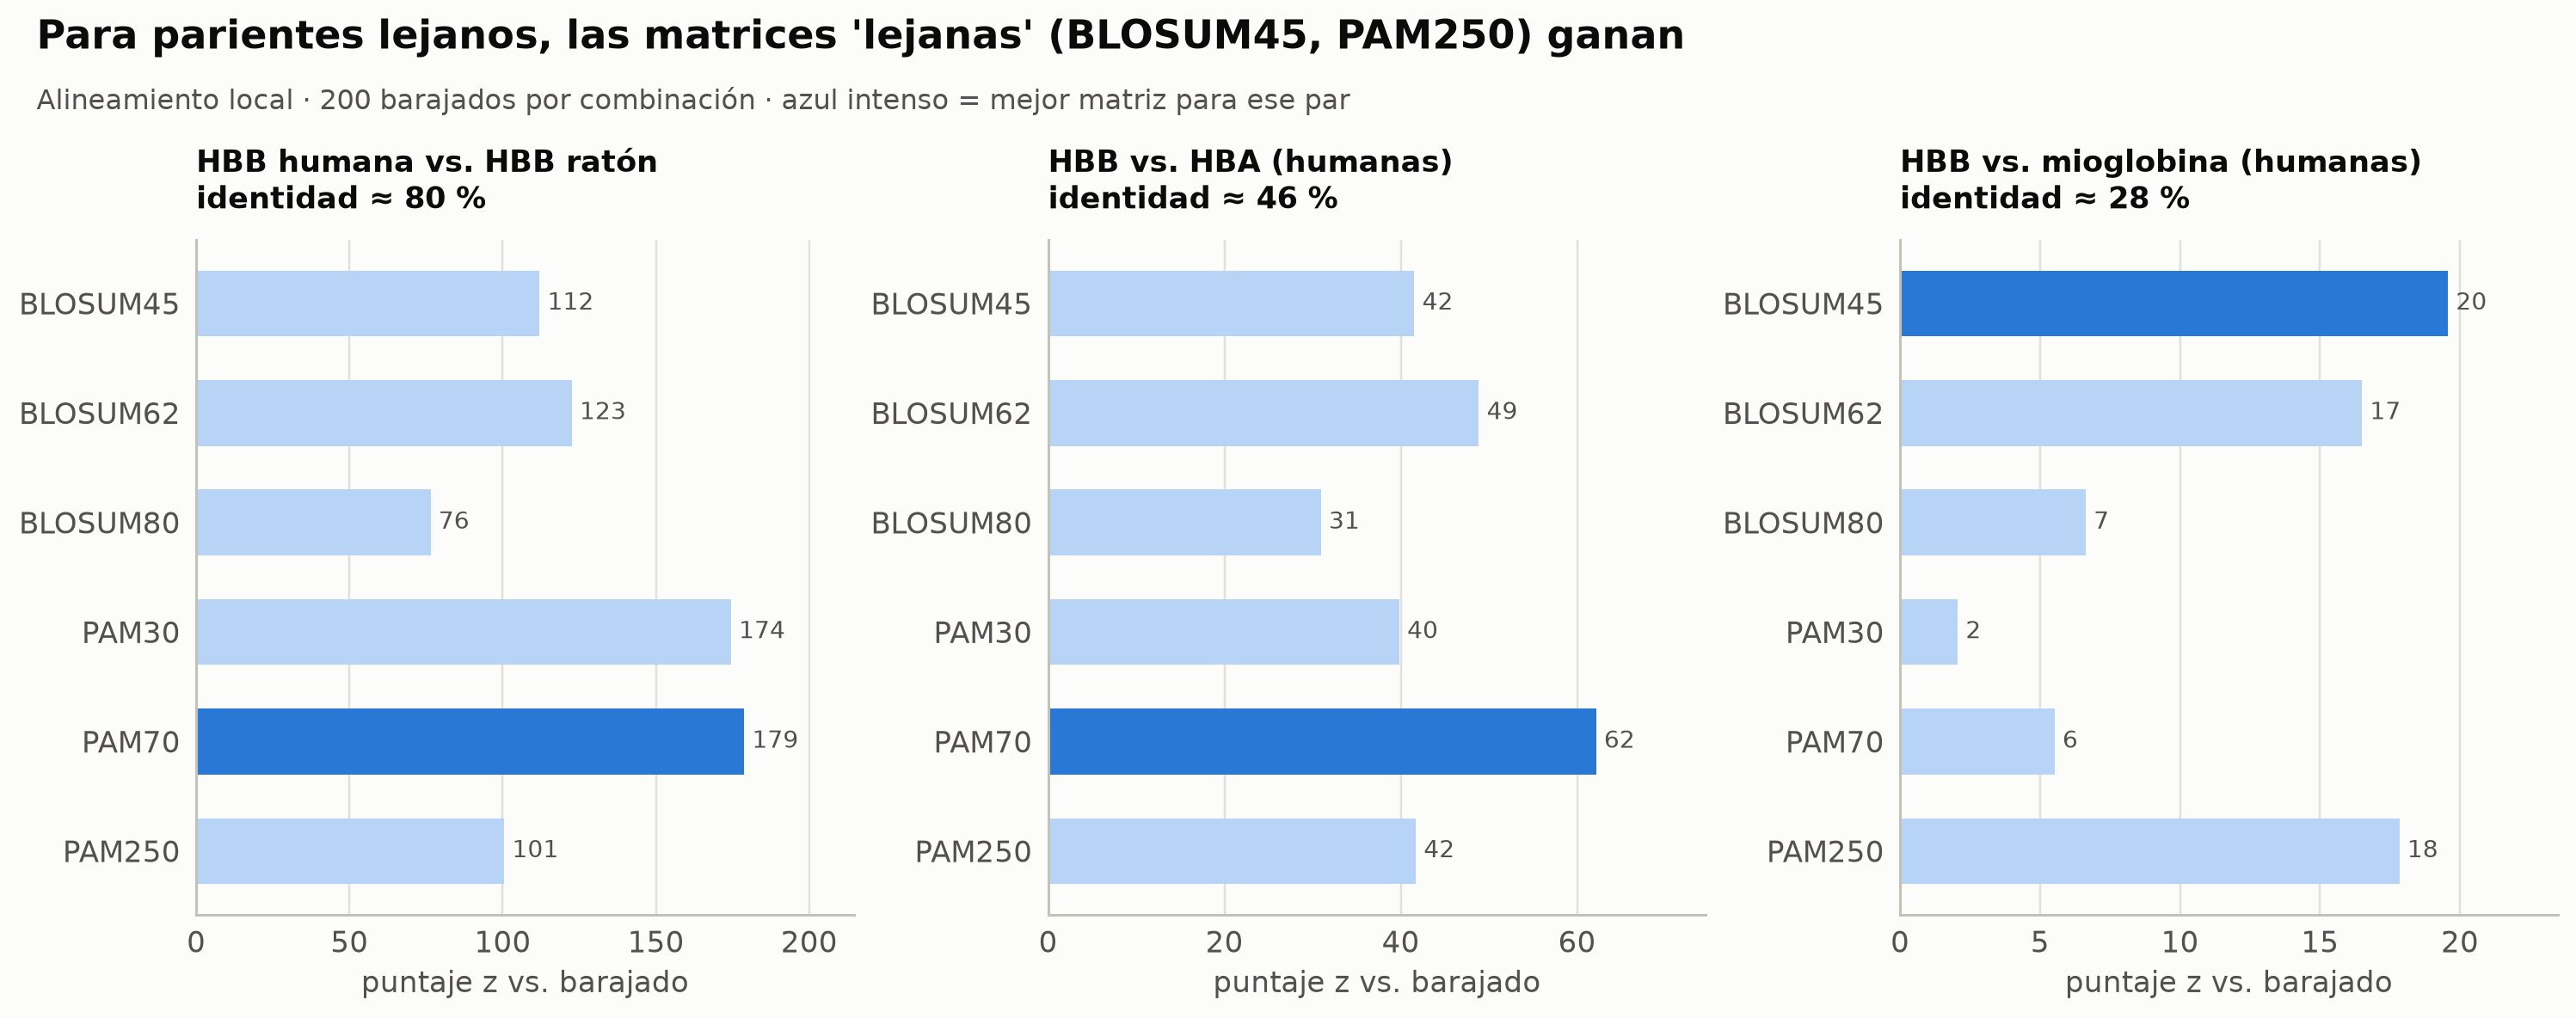

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.6), sharey=False)
for ax, (_, _, label) in zip(axes, pairs_exp):
    sub = res[res["par"] == label].set_index("matriz").loc[list(gap_defaults)]
    best = sub["z"].idxmax()
    colors = [ec.BLUE if m == best else ec.SEQ_BLUE[1] for m in sub.index]
    bars = ax.barh(sub.index[::-1], sub["z"].values[::-1], color=colors[::-1], height=0.6)
    ax.bar_label(bars, fmt="%.0f", padding=3, color=ec.INK_2, fontsize=9)
    ax.set_title(f"{label}\nidentidad ≈ {sub['identidad'].median():.0f} %", fontsize=11.5)
    ax.set_xlim(0, sub["z"].max() * 1.2)
    ax.grid(axis="y", visible=False); ax.grid(axis="x", visible=True)
    ax.set_xlabel("puntaje z vs. barajado")
ec.fig_title(fig, "Para parientes lejanos, las matrices 'lejanas' (BLOSUM45, PAM250) ganan",
             "Alineamiento local · 200 barajados por combinación · azul intenso = mejor matriz para ese par")
plt.show()

> 🔎 **Qué observamos.**
> * Para ortólogos muy parecidos (HBB humana vs. ratón), **todas** las matrices detectan la homología con $z$
>   altísimos; las "cercanas" (PAM70, PAM30) sacan el mayor provecho. Para HBB vs. HBA (~45 % de identidad), gana
>   una matriz intermedia (PAM70).
> * Para el par lejano (HBB vs. mioglobina), el panorama cambia por completo: **PAM30 y BLOSUM80 casi no distinguen
>   la señal del ruido**, mientras que **PAM250 y BLOSUM45** la detectan con claridad. Castigar duramente cada
>   desajuste (como hacen las matrices "cercanas") destruye la señal de un pariente distante.
> * BLOSUM62 es un buen compromiso: nunca es la mejor, pero nunca es mala. Por eso es el valor por defecto de BLASTP.

Veamos la distribución de puntajes barajados contra el puntaje real para el par difícil:

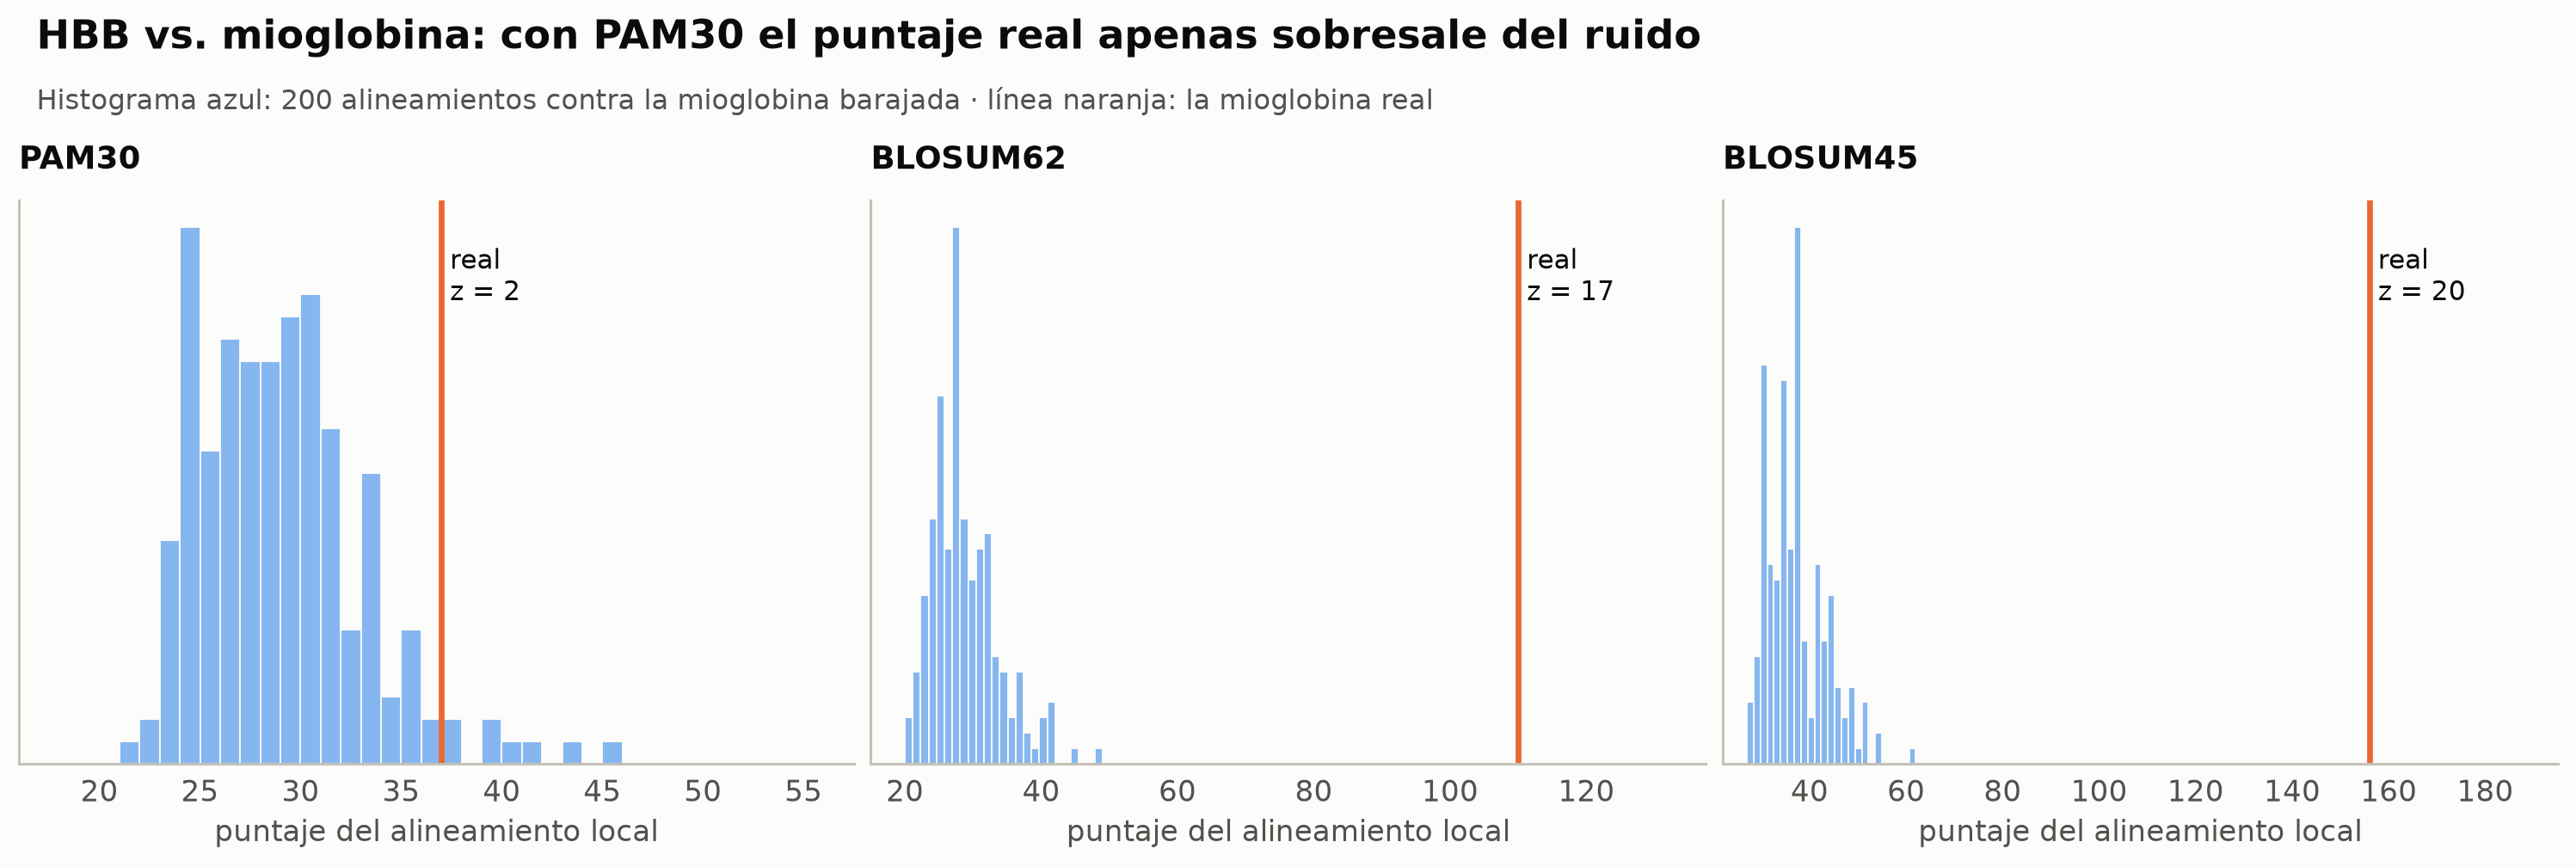

In [22]:
label = pairs_exp[2][2]
fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.8))
for ax, name in zip(axes, ["PAM30", "BLOSUM62", "BLOSUM45"]):
    real, shuffled = shuffles_store[(label, name)]
    ax.hist(shuffled, bins=25, color=ec.SEQ_BLUE[3], edgecolor=ec.SURFACE, linewidth=0.6)
    ax.axvline(real, color=ec.ORANGE, lw=2.2)
    z = (real - shuffled.mean()) / shuffled.std()
    ax.text(real, ax.get_ylim()[1] * 0.92, f" real\n z = {z:.0f}", color=ec.INK, fontsize=10, va="top")
    ax.set_title(name, fontsize=12); ax.set_yticks([]); ax.grid(False)
    ax.set_xlabel("puntaje del alineamiento local")
    ax.set_xlim(min(shuffled.min(), real) - 5, max(shuffled.max(), real) * 1.25)
ec.fig_title(fig, "HBB vs. mioglobina: con PAM30 el puntaje real apenas sobresale del ruido",
             "Histograma azul: 200 alineamientos contra la mioglobina barajada · línea naranja: la mioglobina real")
plt.show()

### 🖱️ ¿Y los huecos? Un barrido interactivo

Para el par difícil (HBB vs. mioglobina) con BLOSUM62, probemos muchas combinaciones de costo de abrir y extender.
Pase el cursor para ver el $z$, el puntaje y el número de huecos del mejor alineamiento.

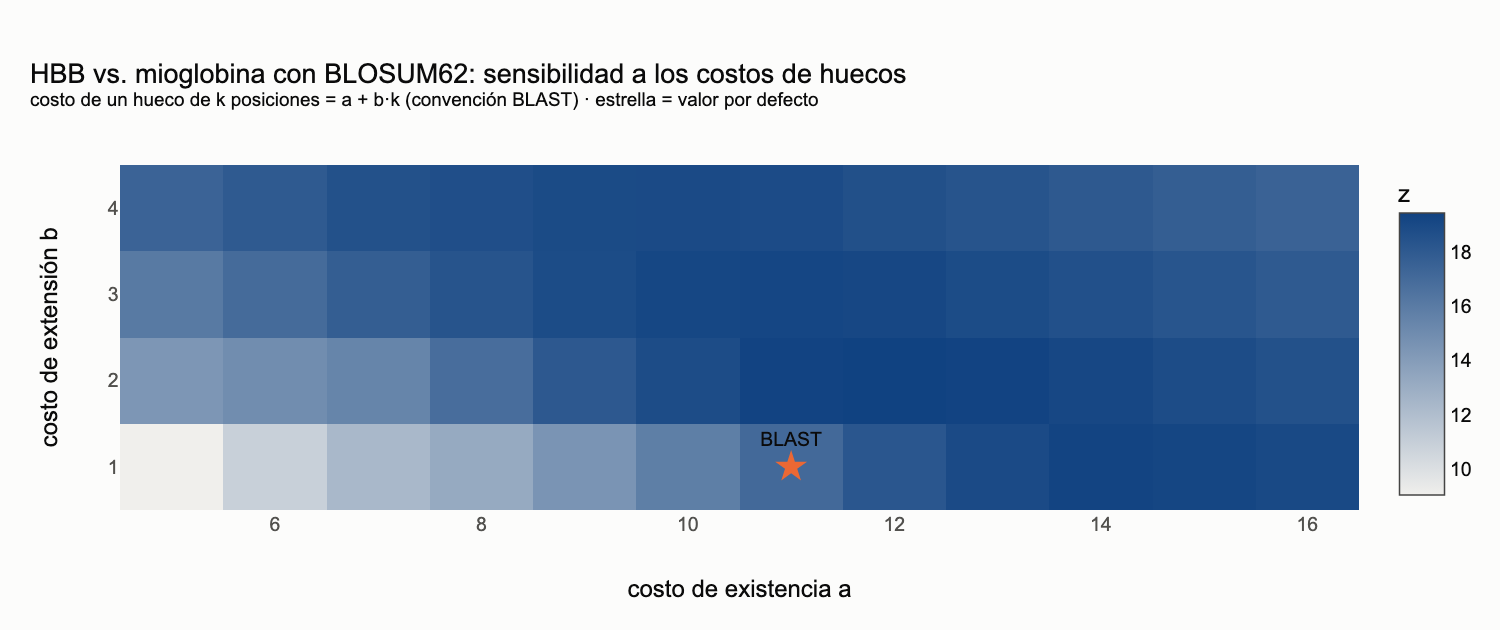

In [23]:
opens = np.arange(5, 17)
exts = np.arange(1, 5)
s1, s2 = globins["HBB_HUMAN"], globins["MYG_HUMAN"]
Z = np.zeros((len(exts), len(opens))); info = [[None] * len(opens) for _ in exts]
for i, b in enumerate(exts):
    for j, a in enumerate(opens):
        al = local_aligner("BLOSUM62", a, b)
        real, shuffled, z = z_score(al, s1, s2, n_shuffles=60, seed=1)
        aln = al.align(s1, s2)[0]
        n_gaps = sum(1 for k in range(1, aln.shape[1]) for row in (0, 1)
                     if aln[row][k] == "-" and aln[row][k - 1] != "-")
        Z[i, j] = z
        info[i][j] = f"abrir a = {a}, extender b = {b}<br>z = {z:.1f} · puntaje = {real:.0f}<br>huecos abiertos: {n_gaps}"
fig = go.Figure(go.Heatmap(z=Z, x=[str(a) for a in opens], y=[str(b) for b in exts], hovertext=info,
                           hoverinfo="text", colorscale=[[0, "#f0efec"], [1, "#104281"]],
                           colorbar=dict(title="z")))
fig.add_trace(go.Scatter(x=["11"], y=["1"], mode="markers+text", text=["BLAST"], textposition="top center",
                         marker=dict(symbol="star", size=16, color="#eb6834"), hoverinfo="skip",
                         showlegend=False))
fig.update_layout(title=dict(text="HBB vs. mioglobina con BLOSUM62: sensibilidad a los costos de huecos"
                                  "<br><sup>costo de un hueco de k posiciones = a + b·k (convención BLAST) · "
                                  "estrella = valor por defecto</sup>"),
                  xaxis_title="costo de existencia a", yaxis_title="costo de extensión b", height=420,
                  margin=dict(t=110))
fig.show()

> 🔎 **Qué observamos.** Los huecos **demasiado baratos** (esquina inferior izquierda) hunden el $z$: permiten
> alineamientos llenos de huecos que también aparecen entre secuencias barajadas, así que el ruido crece tanto como la
> señal. El valor por defecto de BLAST (estrella) cae en una zona razonable, aunque para este par en particular unos
> huecos algo más caros dan un $z$ ligeramente mayor. Los valores por defecto son un **compromiso** que funciona bien
> en millones de búsquedas, no el óptimo de cada par. Y recuerde: matrices y costos de huecos **se eligen juntos**.

> ✅ **Compruebe su comprensión.** Si usted cambia de BLOSUM62 a PAM30, ¿debe mantener los mismos costos de huecos?
> ¿Por qué? *(Pista: la escala de los puntajes de sustitución cambia.)*

## ✍️ Ejercicios

**Ejercicio 1 — Pseudocuentas.** Recalcule la matriz del bloque de juguete (A, S, T) con pseudocuentas 0.1, 0.5 y
2. ¿Qué pasa con el puntaje A–T? ¿Y con A–A? ¿Por qué una pseudocuenta muy grande "aplana" la matriz?

**Ejercicio 2 — Distancia PAM a partir de la identidad.** Dos proteínas tienen 50 % de identidad. Usando la función
`identity(n)` de nuestra cadena de Márkov, estime su distancia en PAMs. ¿Qué matriz de la tabla de la sección 6
recomendaría?

**Ejercicio 3 — Puntaje a mano.** Calcule a mano (con BLOSUM62) el puntaje del alineamiento sin huecos entre
`HEAGAWGHEE` y `HEAGSWGHDE`, y verifíquelo con código.

**Ejercicio 4 — Mioglobina de cachalote.** Repita el experimento de la sección 9 para el par mioglobina humana vs.
mioglobina de cachalote (`MYG_HUMAN` vs. `MYG_PHYMC`). ¿Qué matriz gana ahora? ¿Es consistente con la
identidad entre ellas?

In [24]:
#@title 🔑 Solución — Ejercicio 1 { display-mode: "form" }
for pc in [0.1, 0.5, 2.0]:
    s, _ = blosum_from_blocks(toy, "AST", pseudocount=pc)
    print(f"pseudocuenta {pc:>3}:  A–A = {s.loc['A', 'A']:+.2f}   A–T = {s.loc['A', 'T']:+.2f}   S–T = {s.loc['S', 'T']:+.2f}")
print("Con pseudocuentas grandes todos los pares tienden a la misma frecuencia → los puntajes tienden a 0.")

pseudocuenta 0.1:  A–A = +2.69   A–T = -8.00   S–T = +0.51
pseudocuenta 0.5:  A–A = +2.26   A–T = -4.00   S–T = +0.44
pseudocuenta 2.0:  A–A = +1.41   A–T = -1.61   S–T = +0.30
Con pseudocuentas grandes todos los pares tienden a la misma frecuencia → los puntajes tienden a 0.


In [25]:
#@title 🔑 Solución — Ejercicio 2 { display-mode: "form" }
n_values = np.arange(1, 400)
ids = np.array([identity(n) for n in n_values])
n50 = n_values[np.argmin(np.abs(ids - 0.5))]
print(f"50 % de identidad ≈ PAM{n50}  → una matriz intermedia: BLOSUM62 o BLOSUM80 / PAM70–PAM120.")

50 % de identidad ≈ PAM76  → una matriz intermedia: BLOSUM62 o BLOSUM80 / PAM70–PAM120.


In [26]:
#@title 🔑 Solución — Ejercicio 3 { display-mode: "form" }
x, y = "HEAGAWGHEE", "HEAGSWGHDE"
terms = [int(blosum62[a, b]) for a, b in zip(x, y)]
print(" + ".join(f"{a}{b}:{t:+d}" for (a, b), t in zip(zip(x, y), terms)))
print("Total =", sum(terms))

HH:+8 + EE:+5 + AA:+4 + GG:+6 + AS:+1 + WW:+11 + GG:+6 + HH:+8 + ED:+2 + EE:+5
Total = 56


In [27]:
#@title 🔑 Solución — Ejercicio 4 { display-mode: "form" }
out = []
for name, (a, b) in gap_defaults.items():
    al = local_aligner(name, a, b)
    _, _, z = z_score(al, globins["MYG_HUMAN"], globins["MYG_PHYMC"], n_shuffles=100)
    pid, _ = percent_identity(al, globins["MYG_HUMAN"], globins["MYG_PHYMC"])
    out.append((name, round(z, 1), round(pid, 1)))
print(pd.DataFrame(out, columns=["matriz", "z", "identidad %"]).sort_values("z", ascending=False).to_string(index=False))
print("Son ortólogos cercanos (~80–85 % de identidad): ganan las matrices 'cercanas'.")

  matriz     z  identidad %
   PAM30 196.0         84.4
   PAM70 181.0         84.4
  PAM250 126.4         84.4
BLOSUM45 122.1         84.4
BLOSUM62 121.7         84.4
BLOSUM80  70.9         84.4
Son ortólogos cercanos (~80–85 % de identidad): ganan las matrices 'cercanas'.


## 📌 Resumen

* Los desajustes no valen lo mismo: la **química** de los aminoácidos y el **código genético** hacen que algunas
  sustituciones sean frecuentes entre homólogos y otras rarísimas.
* Un puntaje de sustitución es un **log-odds**: $s(a,b) = \frac{1}{\lambda}\log\frac{q_{ab}}{p_ap_b}$. Positivo =
  más frecuente que por azar. Gracias al logaritmo, el puntaje del alineamiento es una **suma**.
* **BLOSUM** se construye contando pares en bloques alineados; el número indica el umbral de agrupamiento
  (**más alto = secuencias más cercanas**).
* **PAM** modela la evolución como una **cadena de Márkov**: $M^{(n)} = (M^{(1)})^n$ (**más alto = más lejanas**).
  La identidad cae de forma no lineal por las mutaciones múltiples, hasta la zona de penumbra.
* La **entropía relativa** $H$ mide la información por columna y ayuda a elegir matriz: PAM250 ≈ BLOSUM45.
* Los **huecos afines** ($g_{\text{abrir}} + g_{\text{ext}}(k-1)$) reflejan que un indel largo es un solo evento;
  Gotoh los resolvió con tres tablas de programación dinámica.
* Experimentalmente, la matriz decide si detectamos a un pariente lejano: con globinas, BLOSUM45/PAM250 encuentran
  a la mioglobina donde PAM30 casi fracasa.

**Próxima lección (3.4):** BLAST y la estadística de Karlin–Altschul — de puntajes a E-values.

## 📚 Para profundizar

* Dayhoff, M. O., Schwartz, R. M. & Orcutt, B. C. (1978). A model of evolutionary change in proteins. En *Atlas of
  Protein Sequence and Structure*, vol. 5, supl. 3, 345–352.
* Henikoff, S. & Henikoff, J. G. (1992). Amino acid substitution matrices from protein blocks. *PNAS* 89(22):
  10915–10919.
* Altschul, S. F. (1991). Amino acid substitution matrices from an information theoretic perspective. *Journal of
  Molecular Biology* 219(3): 555–565.
* Gotoh, O. (1982). An improved algorithm for matching biological sequences. *Journal of Molecular Biology* 162(3):
  705–708.
* Kyte, J. & Doolittle, R. F. (1982). A simple method for displaying the hydropathic character of a protein.
  *Journal of Molecular Biology* 157(1): 105–132.

---

<sub>**Bioinformática Práctica** · © 2026 Juvenal Yosa, PhD · [juvenal.yosa@gmail.com](mailto:juvenal.yosa@gmail.com) · Código bajo licencia MIT ·
Desarrollado con **Claude** (Anthropic) como copiloto.</sub>

[![Copiloto: Claude](https://img.shields.io/badge/Copiloto-Claude-D97757?logo=claude&logoColor=white)](https://claude.ai)